# Phase 4 — ML Classification

Benchmark ML classifiers against the BLS classical baseline from Phase 3.

**Key failure mode to fix:** BLS false-positive rate on active stars (Class 1) is 90.5%.  
**Goal:** Reduce FPR on Class 1 while maintaining TPR on Classes 2 & 3.

Two approaches:
1. **Tabular ML** (LogReg, RandomForest, XGBoost) — BLS statistics + stellar/activity metadata
2. **1D CNN on phase-folded flux** — learns transit morphology directly

All heavy cells are cached in `data/models/` — restart and re-run safely.

## §0 — Setup

In [1]:
import os
# Prevent the multiple-OpenMP-runtime crash on macOS that occurs when
# XGBoost (libomp) and PyTorch (its own OMP) are loaded in the same kernel.
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"]      = "1"

import sys, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold,cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.inspection import permutation_importance
import xgboost as xgb

plt.style.use("seaborn-v0_8-deep")
plt.rcParams.update({"figure.dpi":300,"font.size":14})

# Paths
ROOT       = Path("..")
DATA_DIR   = ROOT / "data"
MODELS_DIR = DATA_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

H5_PATH  = DATA_DIR / "dataset.h5"
META_CSV = DATA_DIR / "metadata.csv"
BLS_CSV  = DATA_DIR / "bls_results.csv"

sys.path.insert(0, str(ROOT / "simulation"))
from read_dataset import load_dataset, load_metadata

SEED = 42
rng  = np.random.default_rng(SEED)

In [2]:
# ── Cache helpers ──────────────────────────────────────────────────────────────
def pkl_cache(path, fn):
    """Load pickle if it exists, else compute fn() and save."""
    path = Path(path)
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    result = fn()
    with open(path, "wb") as f:
        pickle.dump(result, f)
    return result

def npy_cache(path, fn):
    """Load .npy if it exists, else compute fn() and save."""
    path = Path(path)
    if path.exists():
        return np.load(path)
    result = fn()
    np.save(path, result)
    return result

## §1 — Data Loading & Merging

In [3]:
# Light curves (heavy — only needed for CNN phase-folding in §5)
time, flux, labels_h5, file_ids = load_dataset(str(H5_PATH))
print(f"flux: {flux.shape}, time: {time.shape} days (0 → {time[-1]:.1f})")

flux: (1457, 38880), time: (38880,) days (0 → 270.0)


In [4]:
# Metadata + BLS results → single DataFrame
meta = pd.read_csv(META_CSV, dtype={"file_id": str}, index_col="file_id")
bls  = pd.read_csv(BLS_CSV,  dtype={"file_id": str}, index_col="file_id")

# bls_results.csv is ordered by file_id as in metadata.csv, so we can just join them by index and droping redundant columns
df = meta.copy()
redundant_cols = [col for col in bls.columns if col in df.columns]
df = df.join(bls.drop(columns=redundant_cols), how="left")

print(df.shape) 
df[["label", "planet_present", "bls_power", "bls_depth_ppm"]].describe()

(1457, 46)


,label,planet_present,bls_power,bls_depth_ppm
count,1457.000000,1457.000000,1.457000e+03,1457.000000
mean,1.486616,0.498970,5.495772e+06,161.505323
std,1.116801,0.500171,1.806420e+07,269.945483
min,0.000000,0.000000,7.440589e+03,0.626647
25%,0.000000,0.000000,1.501207e+04,4.142784
50%,1.000000,0.000000,8.014526e+04,27.295214
75%,2.000000,1.000000,1.733218e+06,203.124744
max,3.000000,1.000000,2.343937e+08,1762.599352


In [5]:
print("Class counts:")
print(df["label"].value_counts().sort_index())
print("\nBLS recovered (planet curves only):")
planet_mask = df["planet_present"] == 1
print(df.loc[planet_mask].groupby("label")["recovered"].mean().round(3))

Class counts:
label
0    372
1    358
2    373
3    354
Name: count, dtype: int64

BLS recovered (planet curves only):
label
2    0.960
3    0.895
Name: recovered, dtype: float64


## §2 — Feature Matrix

In [6]:
# Feature columns — no target leakage
FEAT_BLS = ["bls_power", "bls_depth_ppm", "bls_period", "bls_duration"]
FEAT_STELLAR = ["teff", "logg", "star_mass_msun", "star_radius_rsun"]
FEAT_ACT = [
    "rotation_period_days", "inclination_deg", "tau_days", # stellar activity features
    "act_rms", "white_bin", # overall activity features
    "exp_flares","flare_amplitude_ppm", "flare_mean_period_days", # flare features
    "spot_count", "spot_contrast","spot_radius_deg","spot_domega", "spot_latitude_deg", "spot_longitude_deg" # spot features
]
FEATURES = FEAT_BLS + FEAT_STELLAR + FEAT_ACT

X = df[FEATURES].to_numpy(dtype=np.float32)
y_bin = df["planet_present"].to_numpy(dtype=np.int8)   # binary: 0/1
y4    = df["label"].to_numpy(dtype=np.int8)             # 4-class: 0-3

print(f"Feature matrix: {X.shape}")
print(f"Binary target balance: {y_bin.mean():.2%} planet")
print(f"4-class: {np.bincount(y4)}")

Feature matrix: (1457, 22)
Binary target balance: 49.90% planet
4-class: [372 358 373 354]


## §3 — Train / Val / Test Split

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SPLIT_CACHE = MODELS_DIR / "split_indices.npz"

if SPLIT_CACHE.exists():
    sp = np.load(SPLIT_CACHE)
    idx_train, idx_val, idx_test = sp["train"], sp["val"], sp["test"]
    print("Loaded cached split.")
else:
    idx_all = np.arange(len(df))
    idx_tv, idx_test = train_test_split(idx_all, test_size=0.15, stratify=y4, random_state=SEED)
    idx_train, idx_val = train_test_split(idx_tv,  test_size=0.15/0.85, stratify=y4[idx_tv], random_state=SEED)
    np.savez(SPLIT_CACHE, train=idx_train, val=idx_val, test=idx_test)
    print("Split computed and cached.")

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# StandardScaler fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X[idx_train])
X_val   = scaler.transform(X[idx_val])
X_test  = scaler.transform(X[idx_test])

# Targets
yb_train, yb_val, yb_test = y_bin[idx_train], y_bin[idx_val], y_bin[idx_test]
y4_train, y4_val, y4_test = y4[idx_train],   y4[idx_val],    y4[idx_test]

Loaded cached split.
Train: 1019 | Val: 219 | Test: 219


In [8]:
# ── Helper: train-val combined for CV ─────────────────────────────────────────
X_tv  = np.vstack([X_train, X_val])
yb_tv = np.concatenate([yb_train, yb_val])
y4_tv = np.concatenate([y4_train, y4_val])

# Fixed val fold for GridSearchCV (use PredefinedSplit)
from sklearn.model_selection import PredefinedSplit
fold_labels = np.concatenate([-np.ones(len(X_train), dtype=int),
                               np.zeros(len(X_val),   dtype=int)])
ps = PredefinedSplit(fold_labels)

## §4 — Tabular ML

### §4.1 — Train models (LogReg, RF, XGBoost)

In [9]:
# ── Logistic Regression ───────────────────────────────────────────────────────
def train_logreg_binary():
    grid = GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=SEED),
        {"C": [0.01, 0.1, 1.0, 10.0]},
        cv=ps, scoring="roc_auc", refit=True
    )
    grid.fit(X_tv, yb_tv)
    return grid.best_estimator_

def train_logreg_4class():
    grid = GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=SEED),
        {"C": [0.01, 0.1, 1.0, 10.0]},
        cv=ps, scoring="f1_macro", refit=True
    )
    grid.fit(X_tv, y4_tv)
    return grid.best_estimator_

logreg_bin  = pkl_cache(MODELS_DIR / "logreg_binary.pkl",  train_logreg_binary)
logreg_4cls = pkl_cache(MODELS_DIR / "logreg_4class.pkl", train_logreg_4class)
print("LogReg binary  C =", logreg_bin.C)
print("LogReg 4-class C =", logreg_4cls.C)

LogReg binary  C = 1.0
LogReg 4-class C = 10.0


In [10]:
# ── Random Forest ─────────────────────────────────────────────────────────────
def train_rf_binary():
    grid = GridSearchCV(
        RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1),
        {"max_depth": [None, 10, 20], "min_samples_leaf": [1, 3]},
        cv=ps, scoring="roc_auc", refit=True
    )
    grid.fit(X_tv, yb_tv)
    return grid.best_estimator_

def train_rf_4class():
    grid = GridSearchCV(
        RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1),
        {"max_depth": [None, 10, 20], "min_samples_leaf": [1, 3]},
        cv=ps, scoring="f1_macro", refit=True
    )
    grid.fit(X_tv, y4_tv)
    return grid.best_estimator_

rf_bin  = pkl_cache(MODELS_DIR / "rf_binary.pkl",  train_rf_binary)
rf_4cls = pkl_cache(MODELS_DIR / "rf_4class.pkl", train_rf_4class)
print("RF binary  params:", rf_bin.max_depth, rf_bin.min_samples_leaf)
print("RF 4-class params:", rf_4cls.max_depth, rf_4cls.min_samples_leaf)

RF binary  params: 10 3
RF 4-class params: None 1


In [11]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
def train_xgb_binary():
    grid = GridSearchCV(
        xgb.XGBClassifier(
            n_estimators=400,
            eval_metric="logloss", random_state=SEED, n_jobs=-1
        ),
        {"max_depth": [4, 6], "learning_rate": [0.05, 0.1], "subsample": [0.8, 1.0]},
        cv=ps, scoring="roc_auc", refit=True
    )
    grid.fit(X_tv, yb_tv)
    return grid.best_estimator_

def train_xgb_4class():
    grid = GridSearchCV(
        xgb.XGBClassifier(
            n_estimators=400, objective="multi:softprob", num_class=4,
            eval_metric="mlogloss", random_state=SEED, n_jobs=-1
        ),
        {"max_depth": [4, 6], "learning_rate": [0.05, 0.1]},
        cv=ps, scoring="f1_macro", refit=True
    )
    grid.fit(X_tv, y4_tv)
    return grid.best_estimator_

xgb_bin  = pkl_cache(MODELS_DIR / "xgb_binary.pkl",  train_xgb_binary)
xgb_4cls = pkl_cache(MODELS_DIR / "xgb_4class.pkl", train_xgb_4class)
print("XGB binary  params:", xgb_bin.max_depth, xgb_bin.learning_rate)
print("XGB 4-class params:", xgb_4cls.max_depth, xgb_4cls.learning_rate)

XGB binary  params: 4 0.05
XGB 4-class params: 6 0.05


### §4.2 — Binary metrics (planet vs no-planet)

In [12]:
def binary_metrics(model, name):
    """Return dict of per-class TPR/FPR and AUC on the test set."""
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    auc  = roc_auc_score(yb_test, prob)

    # Per-class (label 0-3) TPR on test
    tpr_per = {}
    for cls in range(4):
        mask = (y4_test == cls)
        if mask.sum() == 0:
            tpr_per[cls] = float("nan")
        else:
            # For planet classes (2,3) TPR = recall; for no-planet (0,1) TPR = FPR (predict planet when none)
            tpr_per[cls] = pred[mask].mean()
    return {
        "name": name,
        "fpr_c0": tpr_per[0],   # quiet, no planet → should be ~0
        "fpr_c1": tpr_per[1],   # active, no planet → BLS fails here
        "tpr_c2": tpr_per[2],   # quiet + planet
        "tpr_c3": tpr_per[3],   # active + planet
        "auc":    auc,
        "prob":   prob,
    }

results = {
    "logreg": binary_metrics(logreg_bin, "Logistic Reg"),
    "rf":     binary_metrics(rf_bin,     "Random Forest"),
    "xgb":    binary_metrics(xgb_bin,    "XGBoost"),
}
for r in results.values():
    print(f"{r['name']:15s} FPR(C0)={r['fpr_c0']:.1%}  FPR(C1)={r['fpr_c1']:.1%}  TPR(C2)={r['tpr_c2']:.1%}  "
          f"TPR(C3)={r['tpr_c3']:.1%}  AUC={r['auc']:.3f}")

Logistic Reg    FPR(C0)=12.5%  FPR(C1)=1.9%  TPR(C2)=91.1%  TPR(C3)=94.3%  AUC=0.985
Random Forest   FPR(C0)=0.0%  FPR(C1)=3.7%  TPR(C2)=100.0%  TPR(C3)=96.2%  AUC=0.998
XGBoost         FPR(C0)=0.0%  FPR(C1)=0.0%  TPR(C2)=100.0%  TPR(C3)=96.2%  AUC=0.996


### §4.3 — 4-class confusion matrices

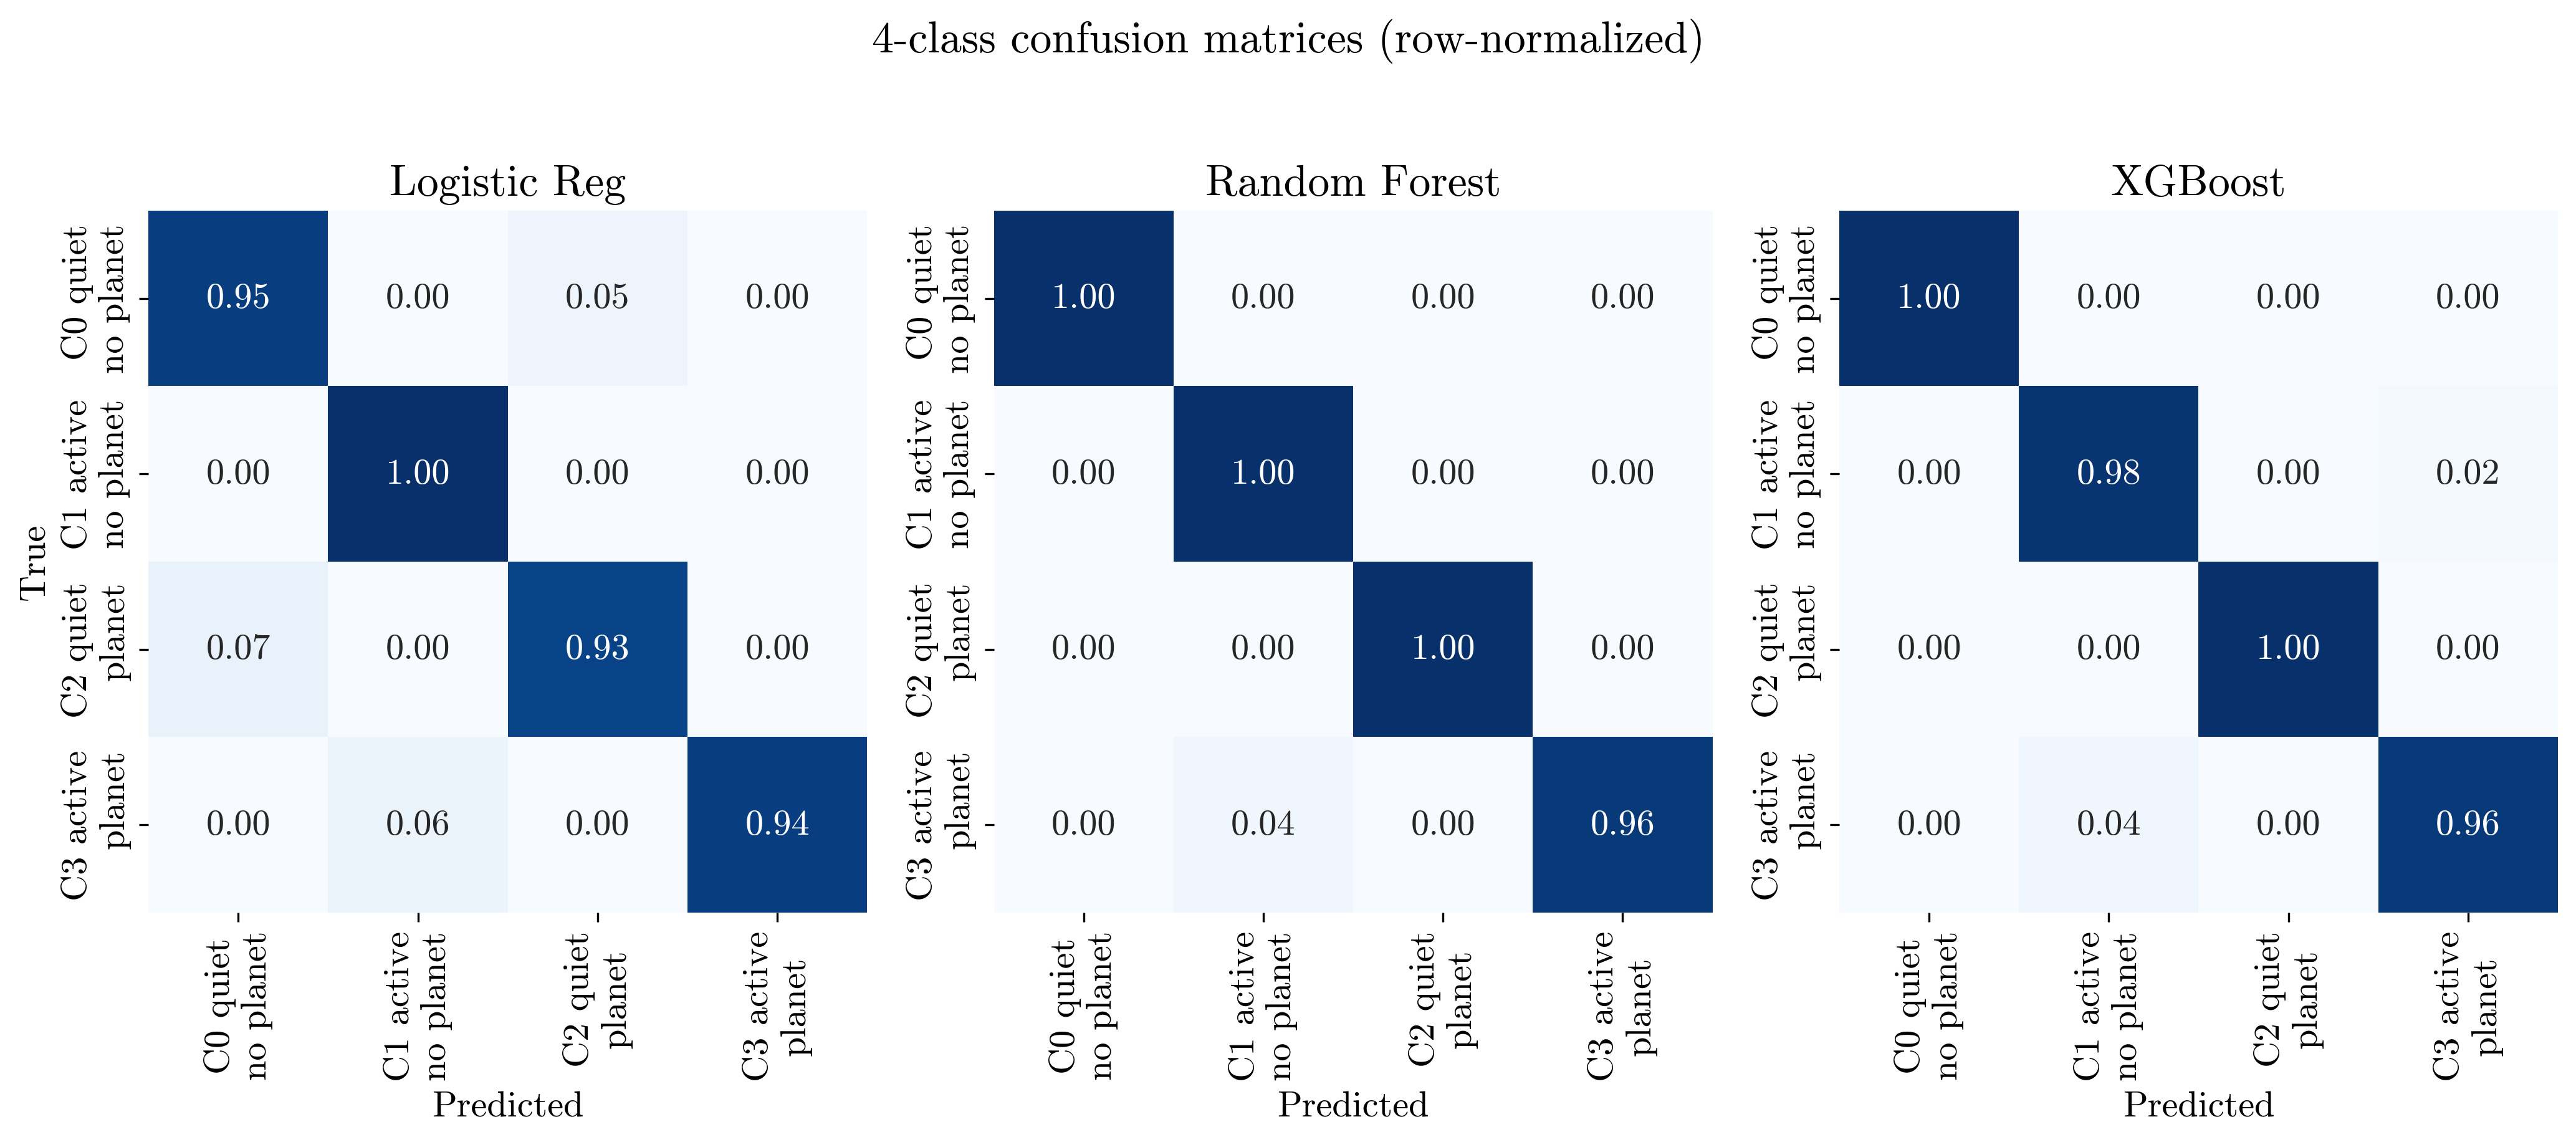

In [54]:
CLASS_NAMES = ["C0 quiet\nno planet", "C1 active\nno planet",
               "C2 quiet\nplanet",    "C3 active\nplanet"]

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
for ax, (key, model, name) in zip(axes, [
    ("logreg", logreg_4cls, "Logistic Reg"),
    ("rf",     rf_4cls,     "Random Forest"),
    ("xgb",    xgb_4cls,    "XGBoost"),
]):
    pred = model.predict(X_test)
    cm   = confusion_matrix(y4_test, pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1, cbar=False)
    ax.set_title(name)
    ax.set_ylabel("True" if ax is axes[0] else "")
    ax.set_xlabel("Predicted")

plt.suptitle("4-class confusion matrices (row-normalized)", y=1.02)
plt.tight_layout()
plt.show()

### §4.4 — Feature importance

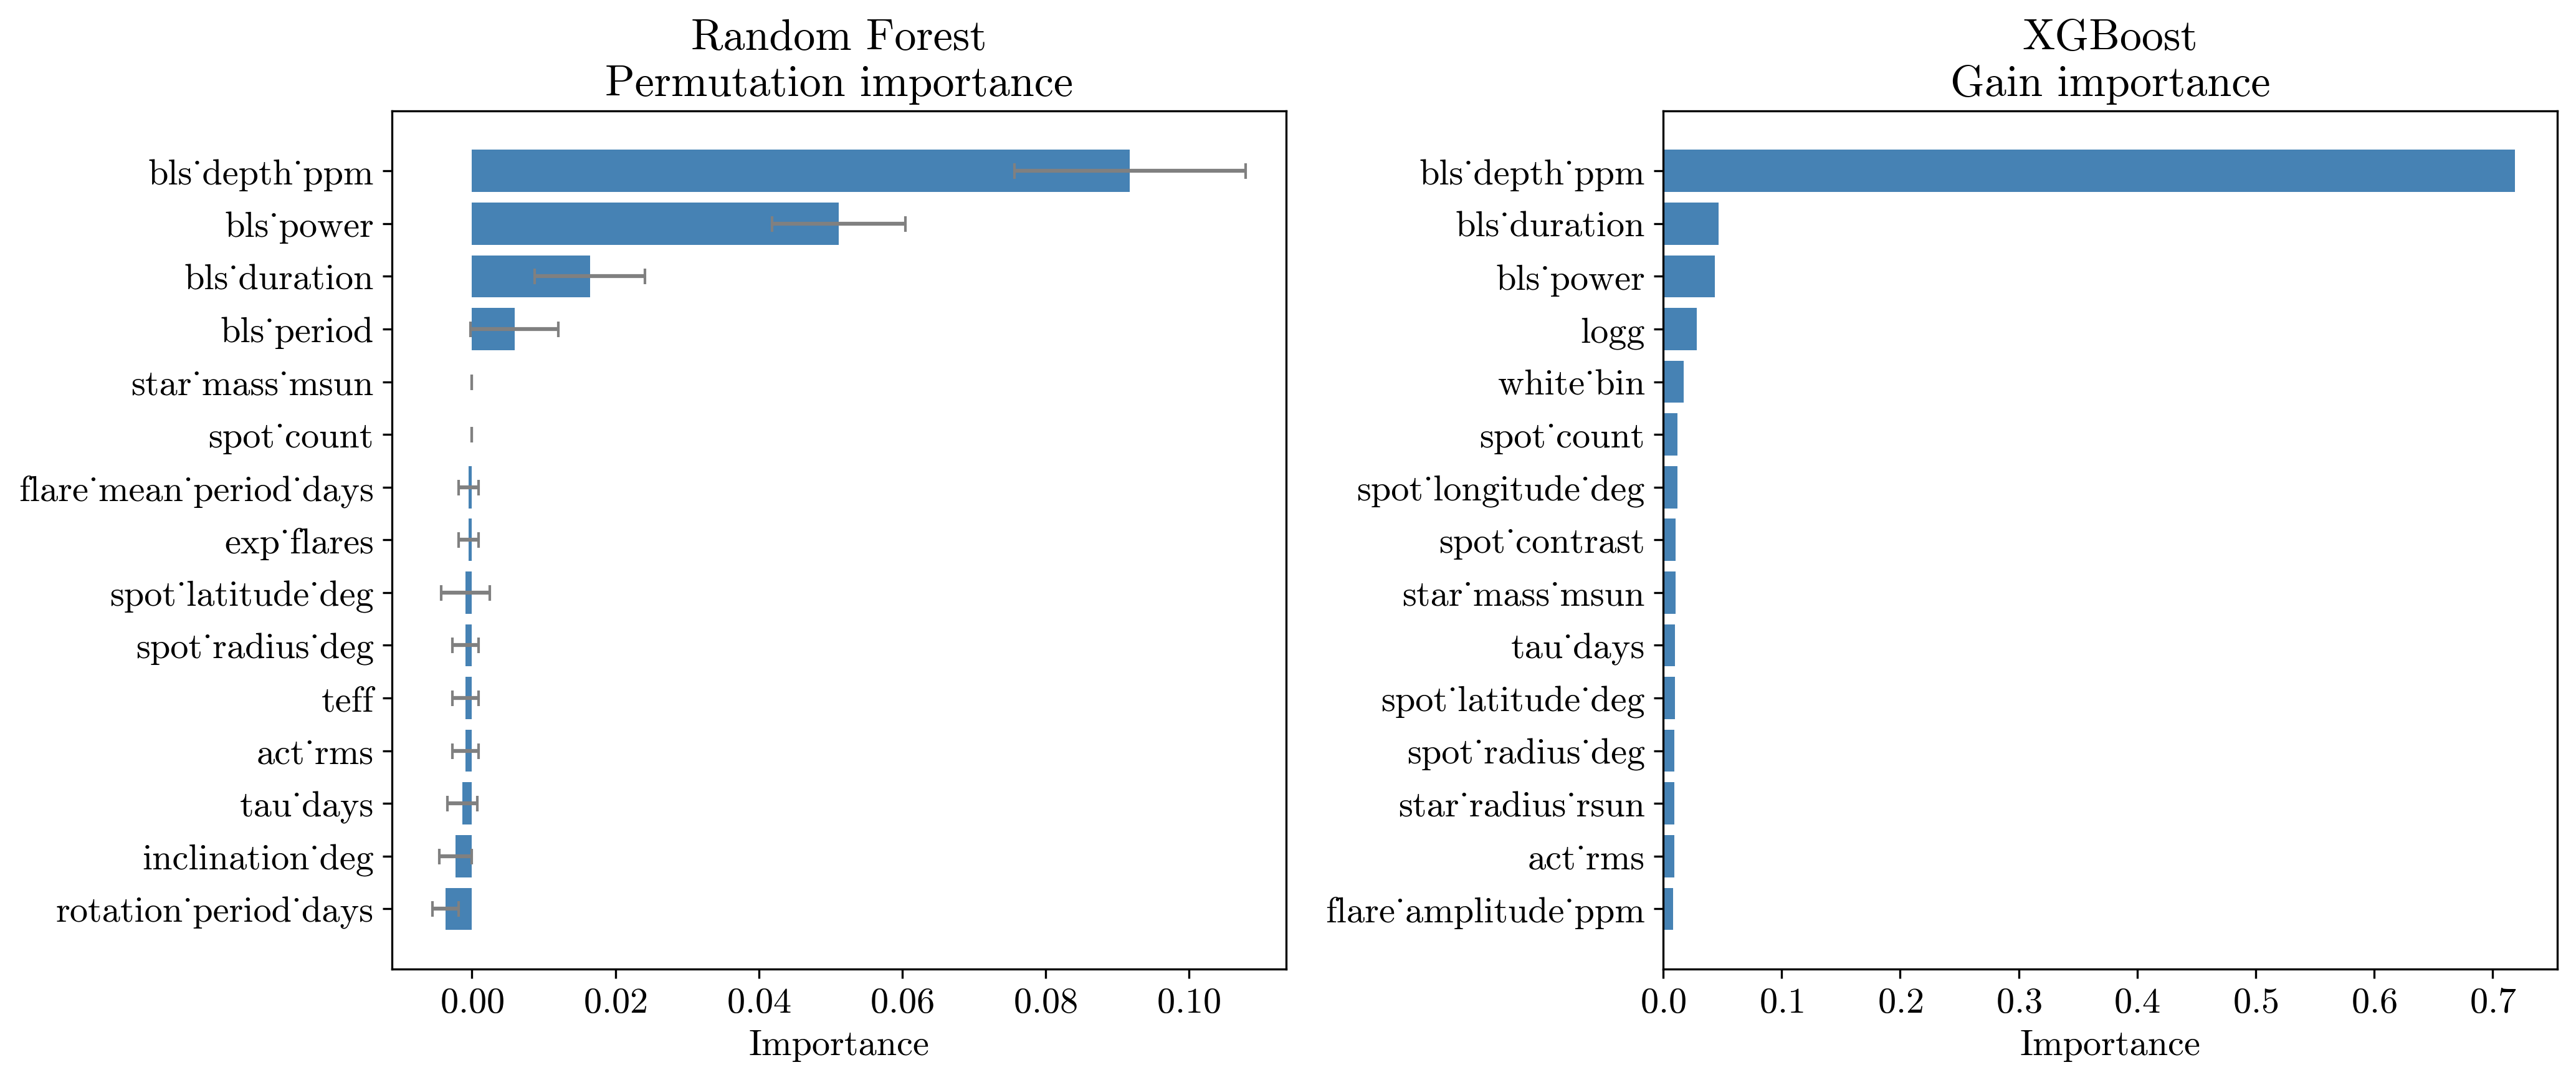

In [14]:
def plot_importance(model, name, ax, top_n=15, use_builtin=False):
    if use_builtin and hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
        err = None
        label = "Gain importance"
    else:
        pi  = permutation_importance(model, X_test, yb_test,
                                     n_repeats=10, random_state=SEED, n_jobs=1)
        imp = pi.importances_mean
        err = pi.importances_std
        label = "Permutation importance"
    order = np.argsort(imp)[-top_n:]
    ax.barh([FEATURES[i] for i in order], imp[order],
            xerr=(err[order] if err is not None else None),
            color="steelblue", ecolor="gray", capsize=3)
    ax.set_title(f"{name}\n{label}")
    ax.set_xlabel("Importance")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_importance(rf_bin,  "Random Forest",  axes[0], use_builtin=False)
plot_importance(xgb_bin, "XGBoost",        axes[1], use_builtin=True)
plt.tight_layout()
plt.show()

### §4.5 — Feature-group ablation: does activity help independent of BLS?
Tests whether stellar/activity metadata carries planet-discriminating signal on its own

In [15]:
_FEAT_BLS_FULL  = ["bls_power", "bls_depth_ppm", "bls_period", "bls_duration"]
_FEAT_BLS_CLEAN = ["bls_period", "bls_duration"]

FEATURE_GROUPS = {
    "BLS (full)":   _FEAT_BLS_FULL,
    "BLS (clean)":  _FEAT_BLS_CLEAN,
    "Stellar+Act":  FEAT_STELLAR + FEAT_ACT,      # the thesis-critical set
    "Act only":     FEAT_ACT,
    "All":          _FEAT_BLS_FULL + FEAT_STELLAR + FEAT_ACT,
}

def make_models():
    """Fresh, modest models — no per-group tuning, so the comparison is clean."""
    return {
        "LogReg": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)),
        "RF": RandomForestClassifier(
            n_estimators=400, max_depth=10, min_samples_leaf=3,
            random_state=SEED, n_jobs=-1),
    }

def fpr_tpr_by_class(y4_true, pred):
    """FPR on C0/C1 (= fraction predicted planet), TPR on C2/C3."""
    return {cls: (pred[y4_true == cls].mean() if (y4_true == cls).any()
                  else float("nan")) for cls in range(4)}

# ── (A) Held-out split ───────────────────────────────────────────────────────
print("=== (A) Held-out test split ===\n")
print(f"{'Features':14s} {'Model':7s} {'AUC':>6s} {'FPR_C1':>7s} {'TPR_C2':>7s} {'TPR_C3':>7s}")
for gname, cols in FEATURE_GROUPS.items():
    Xg = df[cols].to_numpy(dtype=np.float32)
    for mname, model in make_models().items():
        model.fit(Xg[idx_train], yb_train)
        prob = model.predict_proba(Xg[idx_test])[:, 1]
        d = fpr_tpr_by_class(y4_test, (prob >= 0.5).astype(int))
        print(f"{gname:14s} {mname:7s} {roc_auc_score(yb_test, prob):6.3f} "
              f"{d[1]:6.1%} {d[2]:6.1%} {d[3]:6.1%}")

# ── (B) Stratified 5-fold CV, out-of-fold ────────────────────────────────────
print("\n=== (B) Stratified 5-fold CV (out-of-fold, full dataset) ===\n")
print(f"{'Features':14s} {'Model':7s} {'AUC':>6s} {'FPR_C1':>7s} {'TPR_C2':>7s} {'TPR_C3':>7s}")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for gname, cols in FEATURE_GROUPS.items():
    Xg = df[cols].to_numpy(dtype=np.float32)
    for mname, model in make_models().items():
        oof_prob = cross_val_predict(model, Xg, y_bin, cv=skf.split(Xg, y4),
                                     method="predict_proba", n_jobs=-1)[:, 1]
        d = fpr_tpr_by_class(y4, (oof_prob >= 0.5).astype(int))
        cv_rows.append({"Features": gname, "Model": mname,
                        "AUC": roc_auc_score(y_bin, oof_prob),
                        "FPR_C1": d[1], "TPR_C2": d[2], "TPR_C3": d[3]})
        print(f"{gname:14s} {mname:7s} {cv_rows[-1]['AUC']:6.3f} "
              f"{d[1]:6.1%} {d[2]:6.1%} {d[3]:6.1%}")
cv_ablation_df = pd.DataFrame(cv_rows)


=== (A) Held-out test split ===

Features       Model      AUC  FPR_C1  TPR_C2  TPR_C3
BLS (full)     LogReg   0.987   0.0%  92.9%  94.3%
BLS (full)     RF       0.999   1.9% 100.0%  96.2%
BLS (clean)    LogReg   0.902   0.0%  87.5%  86.8%
BLS (clean)    RF       0.985   0.0% 100.0%  96.2%
Stellar+Act    LogReg   0.664  29.6%  55.4%  58.5%
Stellar+Act    RF       0.723  42.6%  75.0%  54.7%
Act only       LogReg   0.610  42.6%  57.1%  56.6%
Act only       RF       0.702  46.3%  75.0%  54.7%
All            LogReg   0.984   0.0%  89.3%  94.3%
All            RF       0.999   1.9% 100.0%  96.2%

=== (B) Stratified 5-fold CV (out-of-fold, full dataset) ===

Features       Model      AUC  FPR_C1  TPR_C2  TPR_C3
BLS (full)     LogReg   0.986   0.8%  95.7%  88.7%
BLS (full)     RF       0.989   2.5%  98.1%  93.5%
BLS (clean)    LogReg   0.923   1.7%  88.7%  84.7%
BLS (clean)    RF       0.980   1.7%  98.4%  92.9%
Stellar+Act    LogReg   0.641  34.6%  53.6%  53.7%
Stellar+Act    RF       0.696  

## §5 — Phase-Folded 1D CNN

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
print("PyTorch:", torch.__version__, "| device:", "cpu")

PyTorch: 2.12.0 | device: cpu


### §5.1 — Phase folding (at BLS period)

In [17]:
from wotan import flatten

N_BINS = 128
FOLDED_CACHE = MODELS_DIR / f"folded_flux_nbins_{N_BINS}.npy"

def phase_fold_all():
    """Detrend each LC with Wotan, then fold at BLS period into N_BINS bins."""
    folded = np.full((len(df), N_BINS), np.nan, dtype=np.float32)

    for i in tqdm(range(len(df))):
        t_lc   = time.copy()          # days
        fl_lc  = flux[i].astype(float)

        # Detrend — same 0.5-day biweight window as Phase 3
        try:
            fl_flat, _ = flatten(t_lc, fl_lc, method="biweight",
                                 window_length=0.5, return_trend=True)
        except Exception:
            fl_flat = fl_lc.copy()

        period = df["bls_period"].iloc[i]
        t0     = df["bls_t0"].iloc[i]

        # Phase in [0, 1)
        phase = ((t_lc - t0) % period) / period

        # Bin into N_BINS equal-width phase bins
        bin_idx = (phase * N_BINS).astype(int).clip(0, N_BINS - 1)
        bin_sum = np.zeros(N_BINS, dtype=np.float64)
        bin_cnt = np.zeros(N_BINS, dtype=np.int32)
        np.add.at(bin_sum, bin_idx, fl_flat)
        np.add.at(bin_cnt, bin_idx, 1)
        with np.errstate(invalid="ignore"):
            binned = np.where(bin_cnt > 0, bin_sum / bin_cnt, np.nan)

        # Fill gaps with linear interpolation
        x = np.arange(N_BINS)
        mask_valid = np.isfinite(binned)
        if mask_valid.sum() > 1:
            binned = np.interp(x, x[mask_valid], binned[mask_valid])

        # Robust normalise: subtract median, divide by MAD
        med = np.nanmedian(binned)
        mad = np.nanmedian(np.abs(binned - med))
        if mad > 0:
            binned = (binned - med) / mad

        folded[i] = binned.astype(np.float32)

        if (i + 1) % 200 == 0:
            print(f"  folded {i+1}/{len(df)}")

    return folded

folded = npy_cache(FOLDED_CACHE, phase_fold_all)
print("Folded array:", folded.shape)

Folded array: (1457, 128)


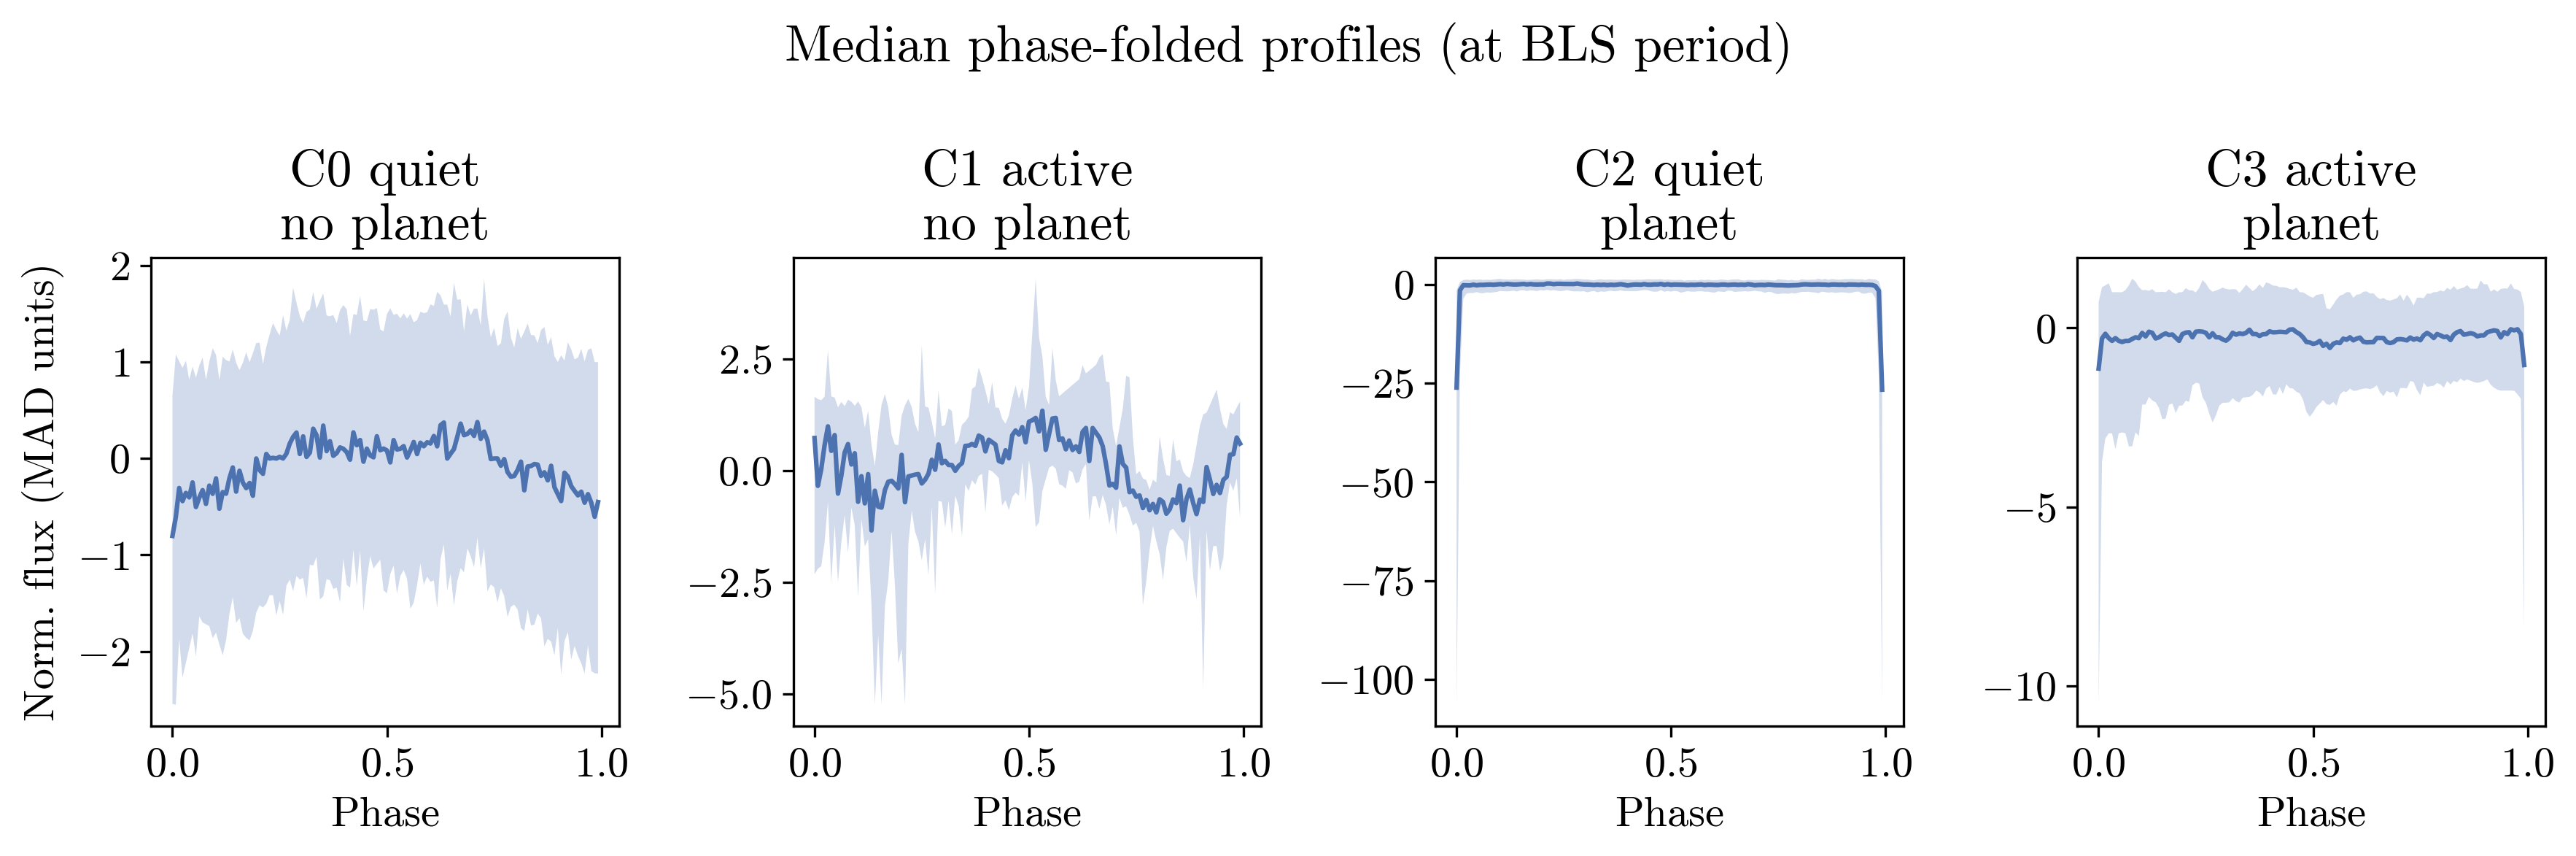

In [80]:
# Visual check: median folded profile per class
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
phase_axis = np.linspace(0, 1, N_BINS, endpoint=False)
for cls, ax in enumerate(axes):
    subset = folded[y4 == cls]
    ax.plot(phase_axis, np.nanmedian(subset, axis=0), lw=1.5)
    ax.fill_between(phase_axis,
                    np.nanpercentile(subset, 16, axis=0),
                    np.nanpercentile(subset, 84, axis=0),
                    alpha=0.25)
    ax.set_title(CLASS_NAMES[cls])
    ax.set_xlabel("Phase")
axes[0].set_ylabel("Norm. flux (MAD units)")
plt.suptitle("Median phase-folded profiles (at BLS period)")
plt.tight_layout()
plt.show()

### §5.2 — CNN model definition

In [19]:
class TransitCNN(nn.Module):
    """Small 1D CNN for phase-folded light curves."""
    def __init__(self, n_classes=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32,  kernel_size=7, padding=3), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128,kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.head(self.encoder(x))

# Quick sanity check
m = TransitCNN()
print(m(torch.zeros(4, 1, N_BINS)).shape)   # expect (4, 1)

torch.Size([4, 1])


### §5.3 — Training (binary)

In [20]:
CNN_BIN_WEIGHTS = MODELS_DIR / f"cnn_binary_{N_BINS}.pt"
CNN_BIN_HISTORY = MODELS_DIR / f"cnn_binary_history_{N_BINS}.pkl"

def train_cnn_binary():
    torch.manual_seed(SEED)

    # Replace any residual NaN bins with 0 (= median level after normalisation)
    folded_clean = np.nan_to_num(folded, nan=0.0)
    Xt = torch.tensor(folded_clean[:, None, :])   # (N, 1, N_BINS)
    yt = torch.tensor(y_bin.astype(np.float32))

    tr_ds  = TensorDataset(Xt[idx_train], yt[idx_train])
    val_ds = TensorDataset(Xt[idx_val],   yt[idx_val])
    tr_dl  = DataLoader(tr_ds,  batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=128)

    pos_weight = torch.tensor([(yb_train == 0).sum() / (yb_train == 1).sum()])
    model     = TransitCNN(n_classes=1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {"train_loss": [], "val_loss": []}
    best_val, patience_cnt = np.inf, 0
    best_state = None

    for epoch in tqdm(range(80), desc="Training binary CNN"):
        model.train()
        tl = []
        for xb, yb_batch in tr_dl:
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(1), yb_batch)
            loss.backward()
            optimizer.step()
            tl.append(loss.item())

        model.eval()
        vl = []
        with torch.no_grad():
            for xb, yb_batch in val_dl:
                vl.append(criterion(model(xb).squeeze(1), yb_batch).item())

        train_loss = float(np.nanmean(tl))
        val_loss   = float(np.nanmean(vl))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        if np.isfinite(val_loss) and val_loss < best_val:
            best_val     = val_loss
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 15:
                print(f"  Early stop at epoch {epoch+1}  best_val={best_val:.4f}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  train={train_loss:.4f}  val={val_loss:.4f}")

    if best_state is None:
        raise RuntimeError("Training produced only NaN losses — check folded input for NaNs.")

    model.load_state_dict(best_state)
    torch.save(best_state, CNN_BIN_WEIGHTS)
    return model, history

# Load or train
if CNN_BIN_WEIGHTS.exists() and CNN_BIN_HISTORY.exists():
    cnn_bin = TransitCNN(n_classes=1)
    cnn_bin.load_state_dict(torch.load(CNN_BIN_WEIGHTS, weights_only=True))
    with open(CNN_BIN_HISTORY, "rb") as f:
        cnn_bin_history = pickle.load(f)
    print("CNN binary loaded from cache.")
else:
    cnn_bin, cnn_bin_history = train_cnn_binary()
    with open(CNN_BIN_HISTORY, "wb") as f:
        pickle.dump(cnn_bin_history, f)
    print("CNN binary trained and cached.")

cnn_bin.eval()
print("Best val loss:", min(cnn_bin_history["val_loss"]))

CNN binary loaded from cache.
Best val loss: 0.46706224977970123


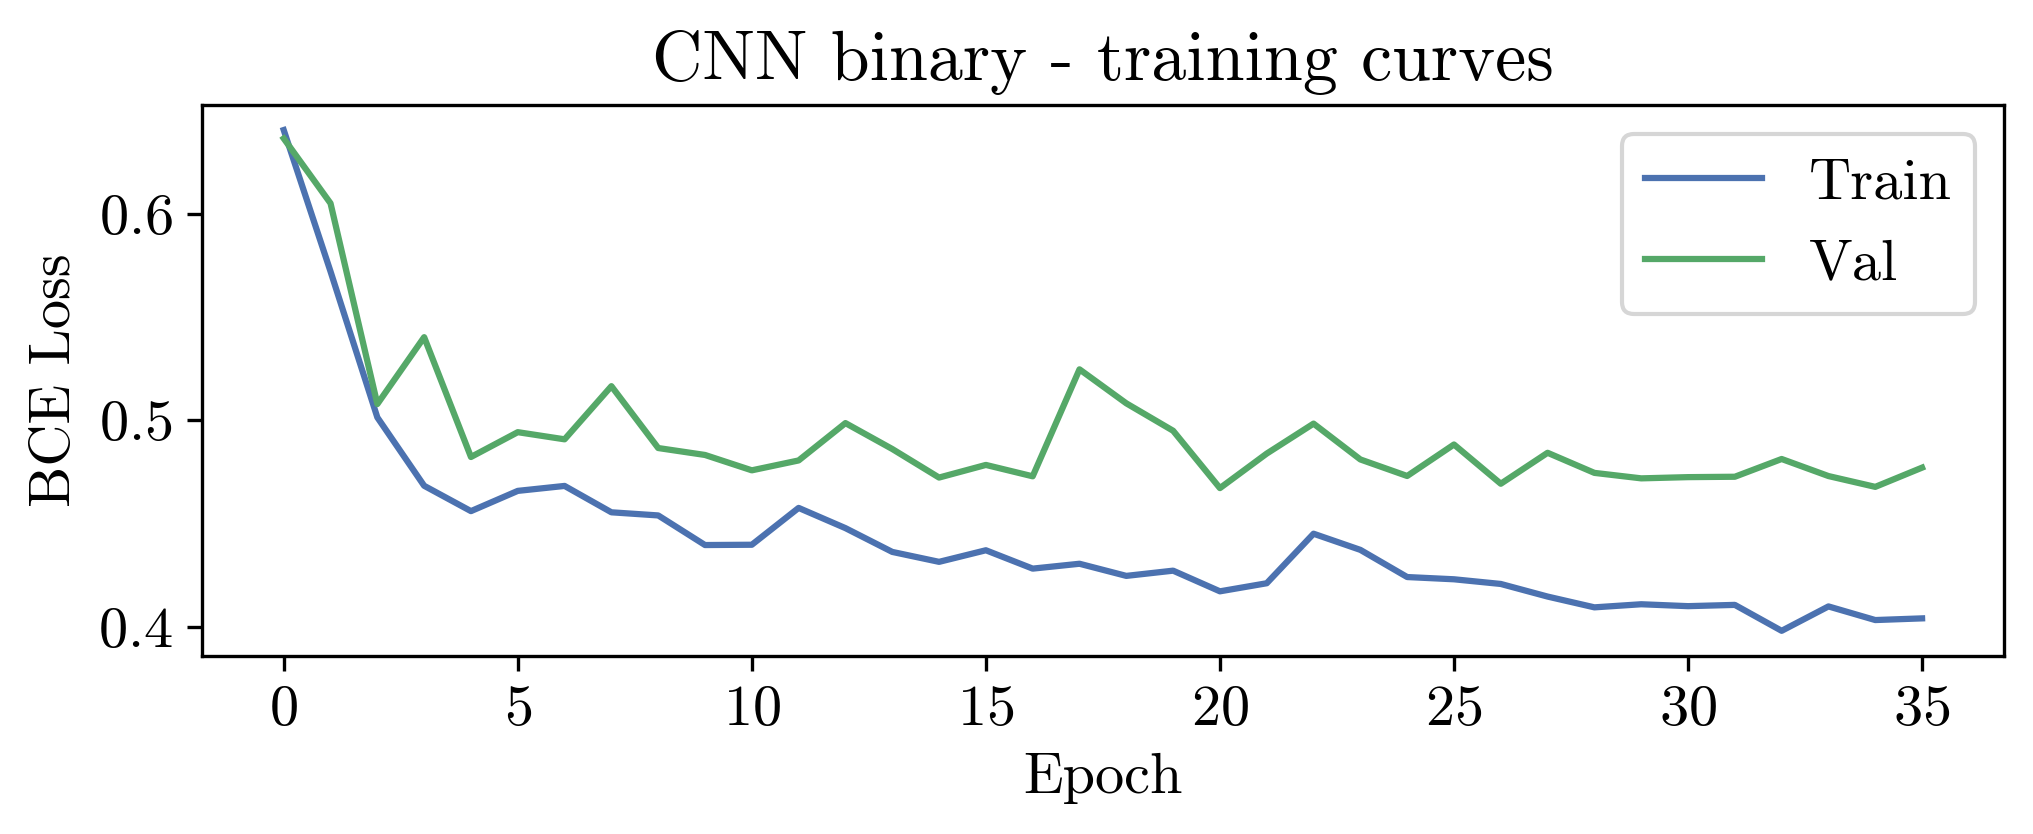

In [21]:
# Loss curves
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(cnn_bin_history["train_loss"], label="Train")
ax.plot(cnn_bin_history["val_loss"],   label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("CNN binary - training curves")
ax.legend()
plt.tight_layout()
plt.show()

### §5.4 — Training (4-class)

In [22]:
CNN_4CLS_WEIGHTS = MODELS_DIR / f"cnn_4class_{N_BINS}.pt"
CNN_4CLS_HISTORY = MODELS_DIR / f"cnn_4class_history_{N_BINS}.pkl"

def train_cnn_4class():
    torch.manual_seed(SEED)

    folded_clean = np.nan_to_num(folded, nan=0.0)
    Xt = torch.tensor(folded_clean[:, None, :])
    yt = torch.tensor(y4.astype(np.int64))

    tr_ds  = TensorDataset(Xt[idx_train], yt[idx_train])
    val_ds = TensorDataset(Xt[idx_val],   yt[idx_val])
    tr_dl  = DataLoader(tr_ds,  batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=128)

    model     = TransitCNN(n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {"train_loss": [], "val_loss": []}
    best_val, patience_cnt = np.inf, 0
    best_state = None

    for epoch in tqdm(range(80), desc="Training 4-class CNN"):
        model.train()
        tl = []
        for xb, yb_batch in tr_dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb_batch)
            loss.backward()
            optimizer.step()
            tl.append(loss.item())

        model.eval()
        vl = []
        with torch.no_grad():
            for xb, yb_batch in val_dl:
                vl.append(criterion(model(xb), yb_batch).item())

        train_loss = float(np.nanmean(tl))
        val_loss   = float(np.nanmean(vl))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        if np.isfinite(val_loss) and val_loss < best_val:
            best_val     = val_loss
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 15:
                print(f"  Early stop at epoch {epoch+1}  best_val={best_val:.4f}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  train={train_loss:.4f}  val={val_loss:.4f}")

    if best_state is None:
        raise RuntimeError("Training produced only NaN losses — check folded input for NaNs.")

    model.load_state_dict(best_state)
    torch.save(best_state, CNN_4CLS_WEIGHTS)
    return model, history

if CNN_4CLS_WEIGHTS.exists() and CNN_4CLS_HISTORY.exists():
    cnn_4cls = TransitCNN(n_classes=4)
    cnn_4cls.load_state_dict(torch.load(CNN_4CLS_WEIGHTS, weights_only=True))
    with open(CNN_4CLS_HISTORY, "rb") as f:
        cnn_4cls_history = pickle.load(f)
    print("CNN 4-class loaded from cache.")
else:
    cnn_4cls, cnn_4cls_history = train_cnn_4class()
    with open(CNN_4CLS_HISTORY, "wb") as f:
        pickle.dump(cnn_4cls_history, f)
    print("CNN 4-class trained and cached.")

cnn_4cls.eval()
print("Best val loss:", min(cnn_4cls_history["val_loss"]))

CNN 4-class loaded from cache.
Best val loss: 0.8843359053134918


### §5.5 — CNN test-set metrics

In [23]:
def cnn_binary_probs(model, indices):
    model.eval()
    folded_clean = np.nan_to_num(folded[indices], nan=0.0)
    Xt = torch.tensor(folded_clean[:, None, :])
    with torch.no_grad():
        logits = model(Xt).squeeze(1)
    return torch.sigmoid(logits).numpy()

cnn_prob_test = cnn_binary_probs(cnn_bin, idx_test)
pred_cnn      = (cnn_prob_test >= 0.5).astype(int)

results["cnn_folded"] = {
    "name":   "1D CNN (folded)",
    "fpr_c0": pred_cnn[y4_test == 0].mean(),
    "fpr_c1": pred_cnn[y4_test == 1].mean(),
    "tpr_c2": pred_cnn[y4_test == 2].mean(),
    "tpr_c3": pred_cnn[y4_test == 3].mean(),
    "auc":    roc_auc_score(yb_test, cnn_prob_test),
    "prob":   cnn_prob_test,
}

for r in results.values():
    print(f"{r['name']:20s} FPR(C0)={r['fpr_c0']:.1%}  FPR(C1)={r['fpr_c1']:.1%}  TPR(C2)={r['tpr_c2']:.1%}  "
          f"TPR(C3)={r['tpr_c3']:.1%}  AUC={r['auc']:.3f}")

Logistic Reg         FPR(C0)=12.5%  FPR(C1)=1.9%  TPR(C2)=91.1%  TPR(C3)=94.3%  AUC=0.985
Random Forest        FPR(C0)=0.0%  FPR(C1)=3.7%  TPR(C2)=100.0%  TPR(C3)=96.2%  AUC=0.998
XGBoost              FPR(C0)=0.0%  FPR(C1)=0.0%  TPR(C2)=100.0%  TPR(C3)=96.2%  AUC=0.996
1D CNN (folded)      FPR(C0)=25.0%  FPR(C1)=1.9%  TPR(C2)=85.7%  TPR(C3)=49.1%  AUC=0.817


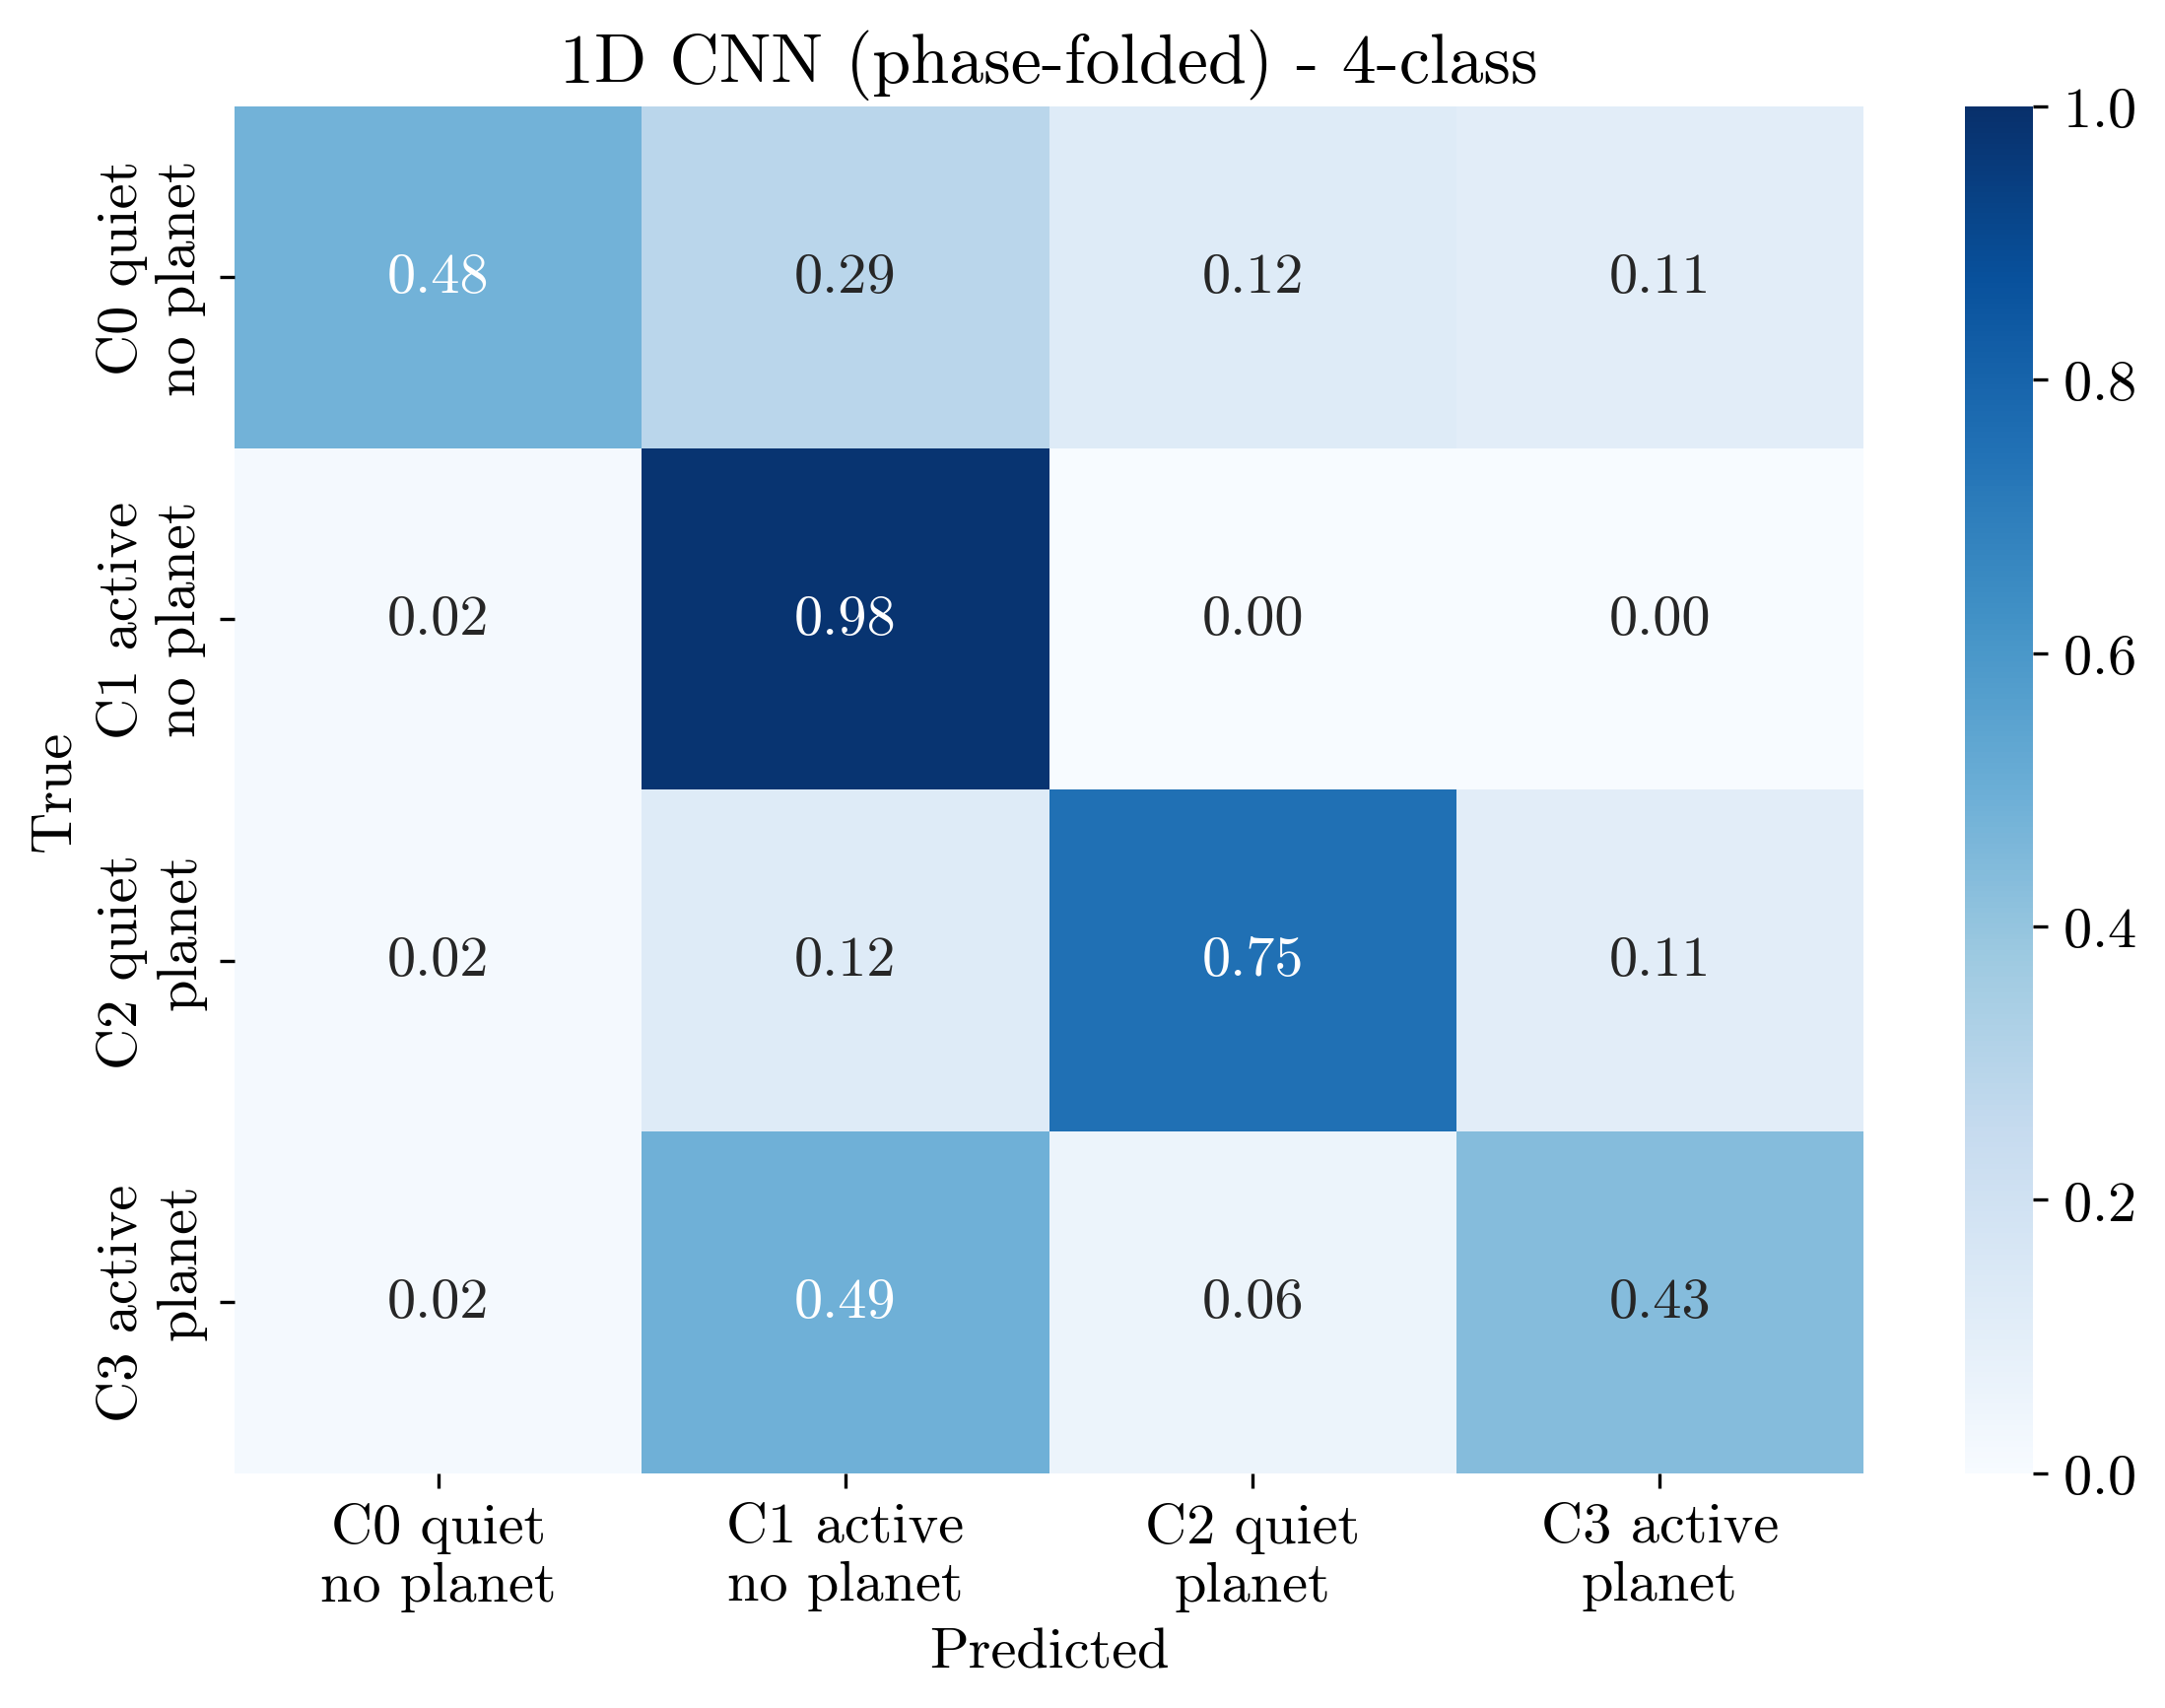

In [55]:
# 4-class confusion for CNN
cnn_4cls.eval()
Xt_test = torch.tensor(np.nan_to_num(folded[idx_test], nan=0.0)[:, None, :])
with torch.no_grad():
    logits_4 = cnn_4cls(Xt_test)
pred_4 = logits_4.argmax(dim=1).numpy()

cm_cnn = confusion_matrix(y4_test, pred_4, normalize="true")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, vmin=0, vmax=1)
ax.set_title("1D CNN (phase-folded) - 4-class")
ax.set_ylabel("True")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## §6 — Unfolded 1D CNN
CNN on the detrended-but-unfolded light curve. No period dependence (nothing to cheat on), no phase-folding S/N boost. Driven entirely by `UNFOLD_CONFIGS`: each variant (detrend window × sequence length) is built, trained, scored, and registered the same way, and everything caches to disk keyed by `(window, seq_len)` so it reloads on restart regardless of cell-run order.

Trained on the single split — compare to the folded CNN (§5), not to the out-of-fold tabular/BLS numbers in §8.

### §6.0 — Configurations & cache paths

In [25]:
# Unfolded-CNN configurations. Add/remove variants here; everything below
# is driven by this list, so the section scales without copy-paste.
#   window  : Wotan detrend window in DAYS (5.0 keeps rotation, 0.5 removes it)
#   seq_len : downsampled sequence length (12960 = 30-min cadence over 270 d;
#             6480 = 1-h cadence matching the Phase-3 baseline)
#   tag     : short label used in results keys and plot titles
UNFOLD_CONFIGS = [
    {"window": 5.0, "seq_len": 12960, "tag": "5.0d", "label": "5.0 d (rotation kept)",    "color": "tab:green"},
    {"window": 0.5, "seq_len": 12960, "tag": "0.5d", "label": "0.5 d (rotation removed)", "color": "tab:orange"},
]
HEADLINE_CFG = UNFOLD_CONFIGS[1]   # which variant becomes results["cnn"] (the operational pick)

# Consistent cache paths — keyed by (window, seq_len) so nothing collides and
# everything reloads on restart regardless of cell-run order.
def _uf_paths(window, seq_len):
    base = f"w{window}_L{seq_len}"
    return {
        "seq":   MODELS_DIR / f"unfolded_seq_{base}.npy",
        "wbin":  MODELS_DIR / f"cnn_unfolded_{base}.pt",
        "hbin":  MODELS_DIR / f"cnn_unfolded_{base}_hist.pkl",
        "w4":    MODELS_DIR / f"cnn_unfold4_{base}.pt",
        "h4":    MODELS_DIR / f"cnn_unfold4_{base}_hist.pkl",
    }

### §6.1 — Detrend & bin (per config, cached)

In [26]:
# Detrend each light curve and bin to seq_len. Parameterized by (window, seq_len);
# cached to disk so a restart reloads instead of recomputing.
def build_unfolded(window, seq_len):
    out   = np.full((len(df), seq_len), np.nan, dtype=np.float32)
    edges = np.linspace(time[0], time[-1], seq_len + 1)
    bidx  = np.clip(np.digitize(time, edges) - 1, 0, seq_len - 1)
    for i in tqdm(range(len(df)), desc=f"Unfolded w={window} L={seq_len}"):
        fl = flux[i].astype(float)
        try:
            flat, _ = flatten(time, fl, method="biweight",
                              window_length=window, return_trend=True)
        except Exception:
            flat = fl.copy()
        s = np.zeros(seq_len); c = np.zeros(seq_len)
        np.add.at(s, bidx, flat); np.add.at(c, bidx, 1)
        with np.errstate(invalid="ignore"):
            b = np.where(c > 0, s / c, np.nan)
        x = np.arange(seq_len); ok = np.isfinite(b)
        if ok.sum() > 1:
            b = np.interp(x, x[ok], b[ok])
        med = np.nanmedian(b); mad = np.nanmedian(np.abs(b - med))
        out[i] = ((b - med) / mad if mad > 0 else b - med).astype(np.float32)
    return out

def get_unfolded(cfg):
    """Load (or build+cache) the unfolded array for one config. NaN-cleaned."""
    p = _uf_paths(cfg["window"], cfg["seq_len"])["seq"]
    arr = npy_cache(p, lambda: build_unfolded(cfg["window"], cfg["seq_len"]))
    return np.nan_to_num(arr, nan=0.0)

# Build all configured variants up front (cached).
unfolded_arrays = {c["tag"]: get_unfolded(c) for c in UNFOLD_CONFIGS}
for c in UNFOLD_CONFIGS:
    print(f"  {c['tag']:5s}: {unfolded_arrays[c['tag']].shape}")

  5.0d : (1457, 12960)
  0.5d : (1457, 12960)


### §6.2 — Model definition (SeqCNN)

In [27]:
# Deeper than TransitCNN (input is up to ~100x longer). AdaptiveAvgPool makes it
# accept any seq_len, so one class serves every config.
class SeqCNN(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64,128, 3, padding=1), nn.BatchNorm1d(128),nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(128,128,3, padding=1), nn.BatchNorm1d(128),nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )
    def forward(self, x): return self.head(self.encoder(x))

### §6.3 — Train / load (binary + 4-class, per config, cached)

In [28]:
# One training routine for both binary and 4-class, any config. Caches weights+history
# keyed by (window, seq_len), so re-running just reloads.
def _train_seqcnn(X, y, n_classes, wpath, hpath, desc):
    torch.manual_seed(SEED)
    Xt = torch.tensor(X[:, None, :])
    if n_classes == 1:
        yt   = torch.tensor(y.astype(np.float32))
        crit = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([(yb_train==0).sum()/(yb_train==1).sum()], dtype=torch.float32))
        squeeze = True
    else:
        yt   = torch.tensor(y.astype(np.int64))
        crit = nn.CrossEntropyLoss()
        squeeze = False
    tr_dl = DataLoader(TensorDataset(Xt[idx_train], yt[idx_train]), batch_size=32, shuffle=True)
    val_dl= DataLoader(TensorDataset(Xt[idx_val],   yt[idx_val]),   batch_size=64)
    model = SeqCNN(n_classes)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)
    hist  = {"train_loss": [], "val_loss": []}; best, wait, best_state = np.inf, 0, None
    for ep in tqdm(range(80), desc=desc):
        model.train(); tl = []
        for xb, yb in tr_dl:
            opt.zero_grad()
            out = model(xb).squeeze(1) if squeeze else model(xb)
            loss = crit(out, yb); loss.backward(); opt.step(); tl.append(loss.item())
        model.eval(); vl = []
        with torch.no_grad():
            for xb, yb in val_dl:
                out = model(xb).squeeze(1) if squeeze else model(xb)
                vl.append(crit(out, yb).item())
        tr_l, va_l = float(np.mean(tl)), float(np.mean(vl))
        hist["train_loss"].append(tr_l); hist["val_loss"].append(va_l); sched.step(va_l)
        if va_l < best: best, best_state, wait = va_l, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else: wait += 1
        if wait >= 15: print(f"  early stop epoch {ep+1} best_val={best:.4f}"); break
        if (ep+1) % 10 == 0: print(f"  epoch {ep+1:3d} train={tr_l:.4f} val={va_l:.4f}")
    model.load_state_dict(best_state)
    torch.save(best_state, wpath)
    with open(hpath, "wb") as f: pickle.dump(hist, f)
    return model, hist

def get_seqcnn(cfg, n_classes):
    """Load (or train+cache) a SeqCNN for one config. Returns (model, history)."""
    p = _uf_paths(cfg["window"], cfg["seq_len"])
    wpath, hpath = (p["wbin"], p["hbin"]) if n_classes == 1 else (p["w4"], p["h4"])
    X = unfolded_arrays[cfg["tag"]]
    if wpath.exists() and hpath.exists():
        m = SeqCNN(n_classes); m.load_state_dict(torch.load(wpath, weights_only=True)); m.eval()
        with open(hpath, "rb") as f: hist = pickle.load(f)
        print(f"  loaded {cfg['tag']} ({'binary' if n_classes==1 else '4-class'}) from cache")
        return m, hist
    y = y_bin if n_classes == 1 else y4
    return _train_seqcnn(X, y, n_classes,
                         wpath, hpath, f"{cfg['tag']} {'bin' if n_classes==1 else '4cls'}")

# Train/load every binary + 4-class variant
cnn_unfold_bin = {c["tag"]: get_seqcnn(c, 1)[0] for c in UNFOLD_CONFIGS}
cnn_unfold_4   = {c["tag"]: get_seqcnn(c, 4)[0] for c in UNFOLD_CONFIGS}

  loaded 5.0d (binary) from cache
  loaded 0.5d (binary) from cache
  loaded 5.0d (4-class) from cache
  loaded 0.5d (4-class) from cache


### §6.4 — Training curves

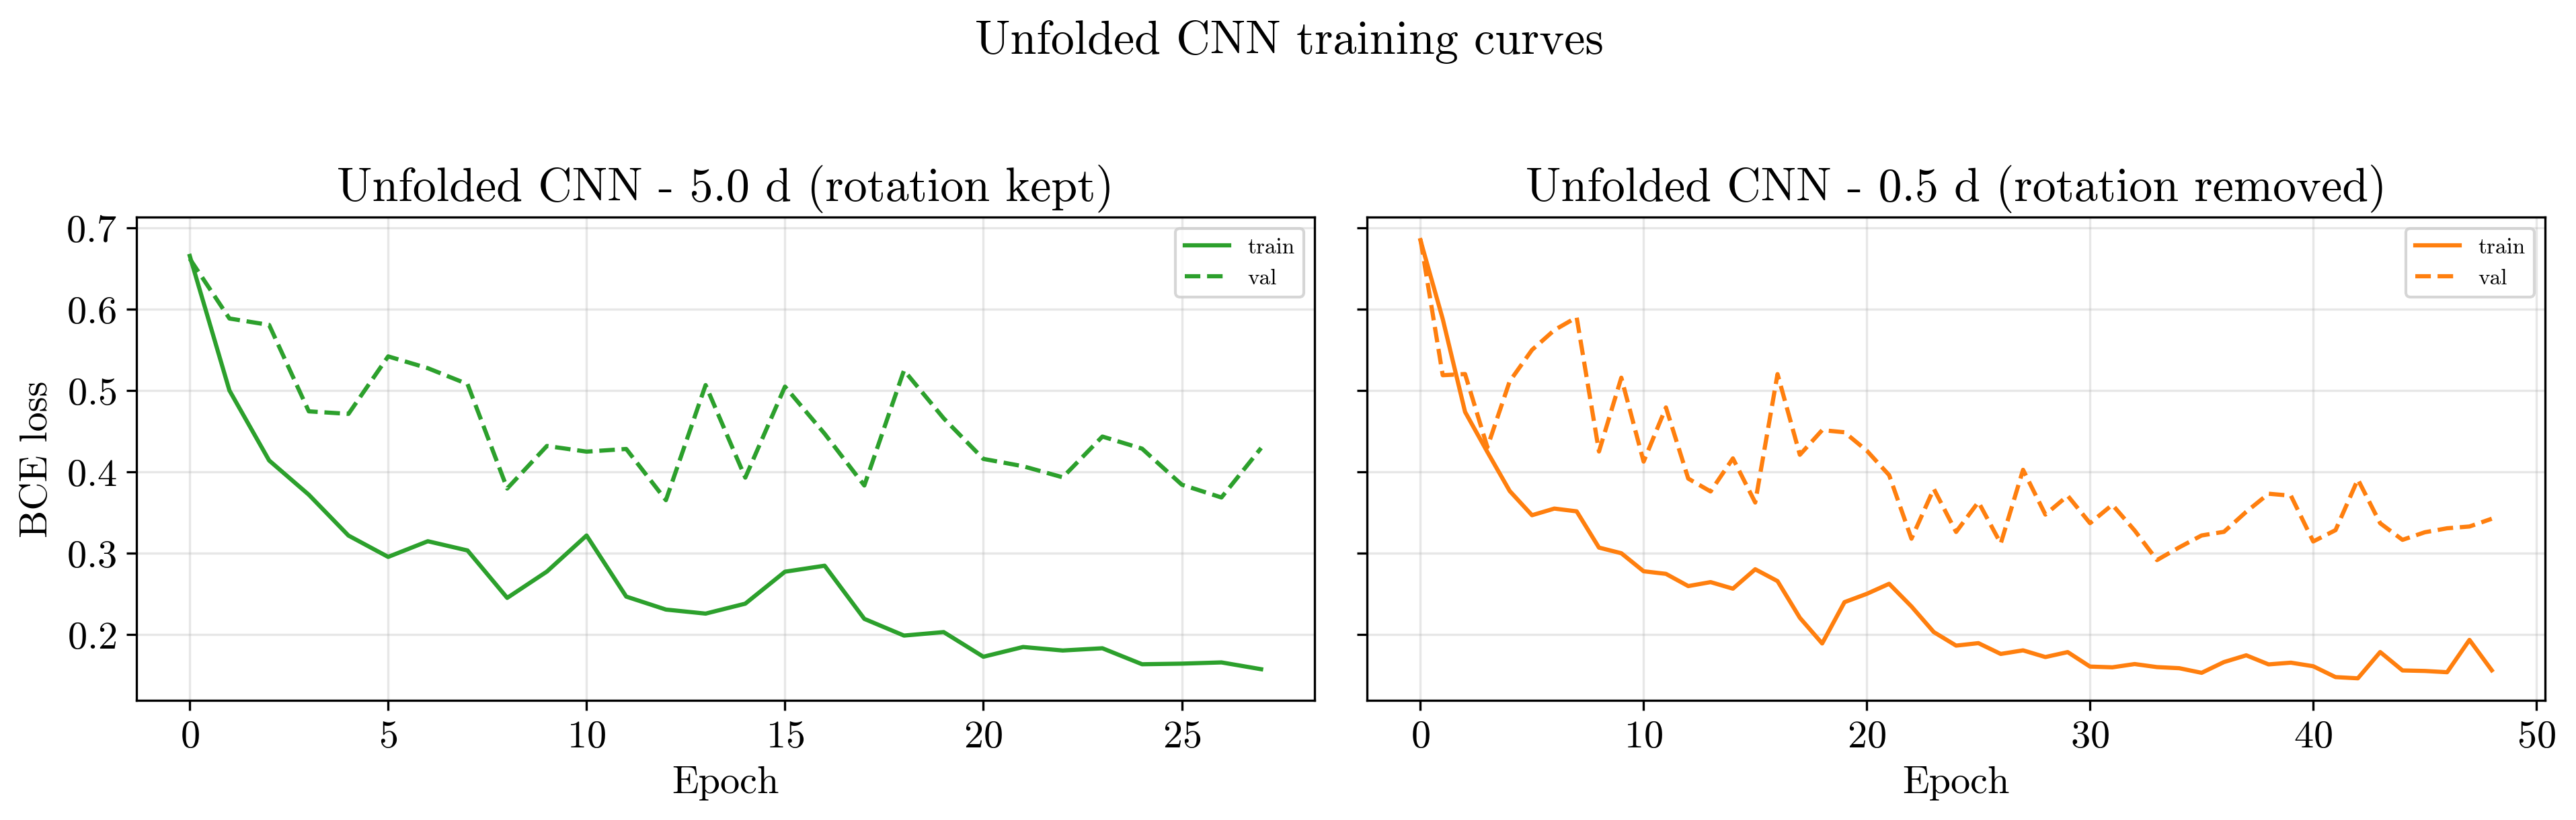

In [29]:
# Training curves for every unfolded variant
fig, axes = plt.subplots(1, len(UNFOLD_CONFIGS), figsize=(6.5*len(UNFOLD_CONFIGS), 4),
                         sharey=True, squeeze=False)
for ax, c in zip(axes[0], UNFOLD_CONFIGS):
    hpath = _uf_paths(c["window"], c["seq_len"])["hbin"]
    with open(hpath, "rb") as f: h = pickle.load(f)
    ax.plot(h["train_loss"], label="train", color=c["color"])
    ax.plot(h["val_loss"],   label="val",   color=c["color"], ls="--")
    ax.set_title(f"Unfolded CNN - {c['label']}"); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)
axes[0][0].set_ylabel("BCE loss")
plt.suptitle("Unfolded CNN training curves", y=1.02); plt.tight_layout(); plt.show()

### §6.5 — Test-set metrics

In [30]:
def _pack(name, prob):
    pred = (prob >= 0.5).astype(int)
    return {"name": name,
            "fpr_c0": pred[y4_test == 0].mean(), "fpr_c1": pred[y4_test == 1].mean(),
            "tpr_c2": pred[y4_test == 2].mean(), "tpr_c3": pred[y4_test == 3].mean(),
            "auc":    roc_auc_score(yb_test, prob), "prob": prob}

def _unfold_test_prob(cfg):
    X = unfolded_arrays[cfg["tag"]][idx_test]
    m = cnn_unfold_bin[cfg["tag"]]; m.eval()
    with torch.no_grad():
        return torch.sigmoid(m(torch.tensor(X[:, None, :])).squeeze(1)).numpy()

# every unfolded variant
for c in UNFOLD_CONFIGS:
    results[f"cnn_unfolded_{c['tag']}"] = _pack(f"1D CNN (unfolded {c['tag']})", _unfold_test_prob(c))

print(f"{'variant':28s} {'FPR_C0':>7s} {'FPR_C1':>7s} {'TPR_C2':>7s} {'TPR_C3':>7s} {'AUC':>6s}")
for k in ["cnn_folded"] + [f"cnn_unfolded_{c['tag']}" for c in UNFOLD_CONFIGS]:
    r = results[k]
    print(f"{r['name']:28s} {r['fpr_c0']:6.1%} {r['fpr_c1']:6.1%} "
          f"{r['tpr_c2']:6.1%} {r['tpr_c3']:6.1%} {r['auc']:6.3f}")

variant                       FPR_C0  FPR_C1  TPR_C2  TPR_C3    AUC
1D CNN (folded)               25.0%   1.9%  85.7%  49.1%  0.817
1D CNN (unfolded 5.0d)         0.0%   0.0%  80.4%  54.7%  0.938
1D CNN (unfolded 0.5d)         1.8%   3.7%  96.4%  81.1%  0.980


### §6.6 — 4-class confusion matrices

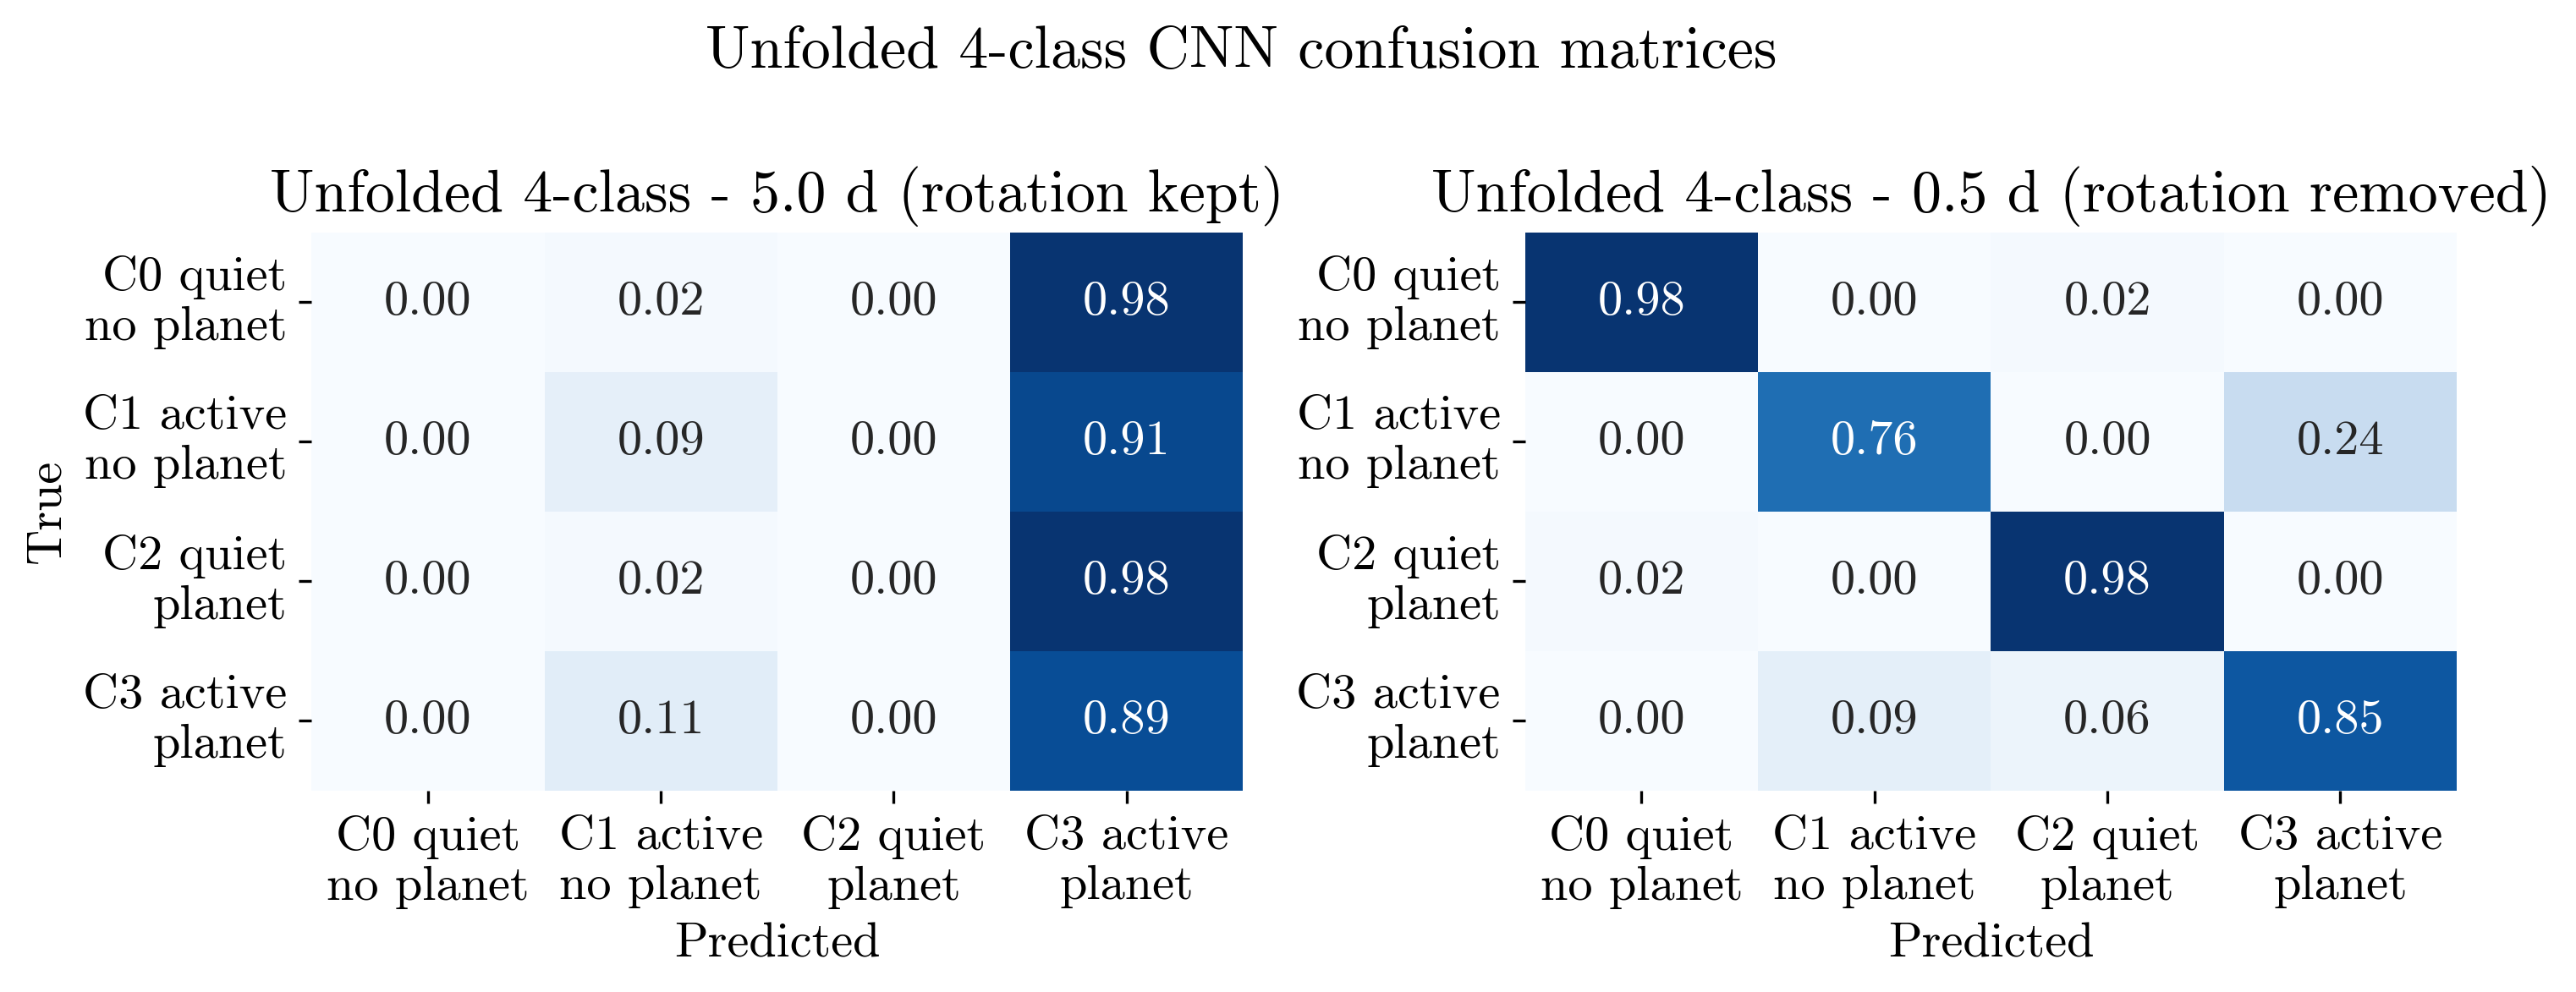

In [46]:
# 4-class confusion matrices for every unfolded variant
fig, axes = plt.subplots(1, len(UNFOLD_CONFIGS), figsize=(5*len(UNFOLD_CONFIGS), 4), squeeze=False)
for ax, c in zip(axes[0], UNFOLD_CONFIGS):
    Xt = torch.tensor(unfolded_arrays[c["tag"]][idx_test][:, None, :])
    with torch.no_grad():
        pred4 = cnn_unfold_4[c["tag"]](Xt).argmax(1).numpy()
    cm = confusion_matrix(y4_test, pred4, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1, cbar=False)
    ax.set_title(f"Unfolded 4-class - {c['label']}")
    ax.set_xlabel("Predicted")
axes[0][0].set_ylabel("True")
plt.suptitle("Unfolded 4-class CNN confusion matrices")
plt.tight_layout() 
plt.show()

### §6.7 — Folded vs Unfolded CNN: head-to-head (same split, same test set)

Model                        AUC |        FPR_C0        FPR_C1        TPR_C2        TPR_C3
----------------------------------------------------------------------------------------------------
1D CNN (folded)            0.817 | 25.0%[20%-31%]   1.9%[1%-5%] 85.7%[80%-90%] 49.1%[42%-56%]
1D CNN (unfolded 5.0d)     0.938 |   0.0%[0%-2%]   0.0%[0%-2%] 80.4%[75%-85%] 54.7%[48%-61%]
1D CNN (unfolded 0.5d)     0.980 |   1.8%[1%-5%]   3.7%[2%-7%] 96.4%[93%-98%] 81.1%[75%-86%]


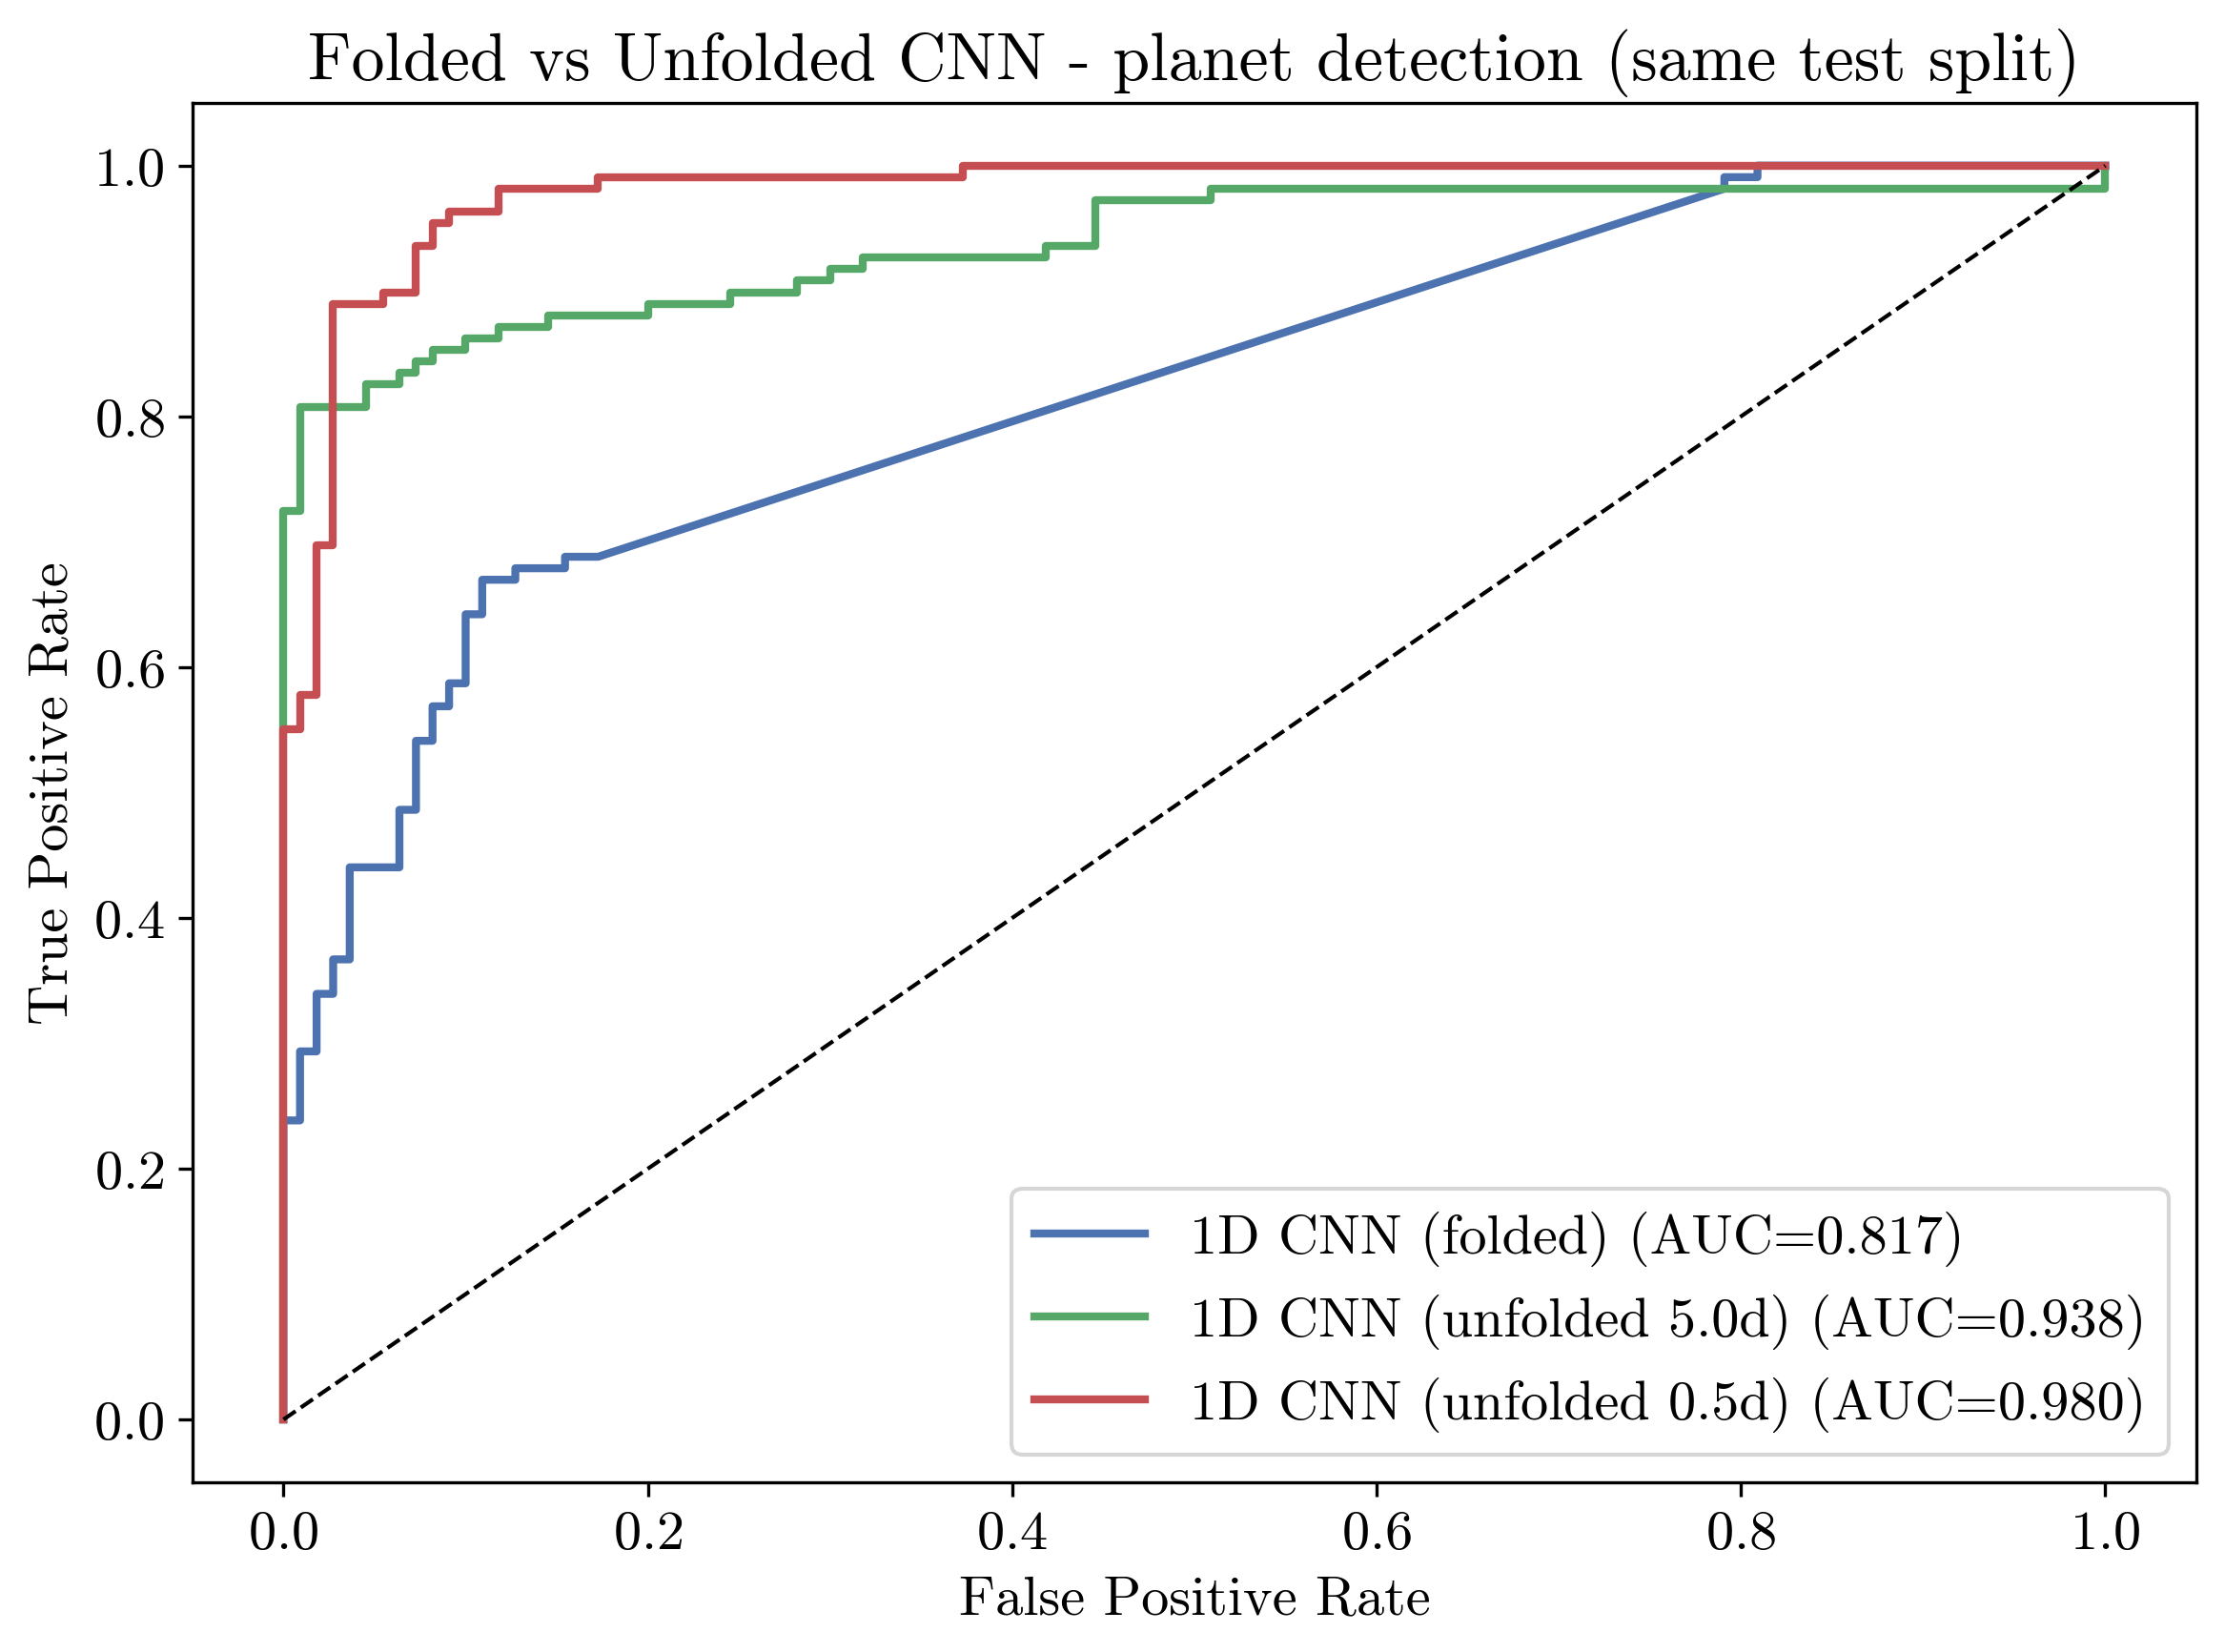

In [56]:
from math import sqrt
def wilson(k, n, z=1.0):
    if n == 0: return (float("nan"),)*3
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    h = z*sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return p, max(0,c-h), min(1,c+h)

def _ci(prob, cls, positive_call=1):
    m = (y4_test == cls); pred = (prob >= 0.5).astype(int)
    p, lo, hi = wilson((pred[m]==positive_call).sum(), m.sum())
    return f"{p:5.1%}[{lo:.0%}-{hi:.0%}]"

H2H_KEYS = ["cnn_folded"] + [f"cnn_unfolded_{c['tag']}" for c in UNFOLD_CONFIGS]

print(f"{'Model':26s} {'AUC':>5s} | {'FPR_C0':>13s} {'FPR_C1':>13s} {'TPR_C2':>13s} {'TPR_C3':>13s}")
print("-"*100)
for k in H2H_KEYS:
    r = results[k]; prob = r["prob"]
    print(f"{r['name']:26s} {r['auc']:5.3f} | "
          f"{_ci(prob,0):>13s} {_ci(prob,1):>13s} {_ci(prob,2):>13s} {_ci(prob,3):>13s}")

fig, ax = plt.subplots(figsize=(8, 6))
for k in H2H_KEYS:
    r = results[k]
    fpr, tpr, _ = roc_curve(yb_test, r["prob"])
    ax.plot(fpr, tpr, lw=2, label=f"{r['name']} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Folded vs Unfolded CNN - planet detection (same test split)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

### §6.8 — Which activity component drives the false alarms?

In [33]:
# Which activity component drives the unfolded model's C1 false alarms?
# Uses the HEADLINE unfolded variant (results["cnn_unfolded_0.5d"]). At n(C1)~50 the group-mean
# differences below are NOT significant — attribution needs the controlled
# spots/flares/both generation run (see Summary). This is a hint, not a result.
c1_mask = (y4_test == 1)
pred_c1 = (results["cnn_unfolded_0.5d"]["prob"][c1_mask] >= 0.5).astype(int)
flagged = pred_c1 == 1
df_c1   = df.iloc[idx_test][c1_mask]
print(f"Headline model: {results['cnn_unfolded_0.5d']['name']}  |  flagged {flagged.sum()}/{c1_mask.sum()} C1 curves\n")
print(f"{'column':22s} {'flagged':>10s} {'not-flagged':>12s}")
for col in ["act_rms", "exp_flares", "flare_amplitude_ppm", "spot_count", "rotation_period_days"]:
    if col in df_c1.columns:
        hi = df_c1[col].values[flagged].mean()
        lo = df_c1[col].values[~flagged].mean()
        print(f"{col:22s} {hi:10.2f} {lo:12.2f}")

Headline model: 1D CNN (unfolded 0.5d)  |  flagged 2/54 C1 curves

column                    flagged  not-flagged
act_rms                    367.43       240.99
exp_flares                  90.39       142.86
flare_amplitude_ppm        538.65       326.76
spot_count                   4.00         3.58
rotation_period_days        12.40        15.10


## §7 — Comparison Table, ROC & Imbalanced-Detection Metrics

### §7.1 — Comparison table & ROC curves

In [34]:
# BLS baseline numbers (from Phase 3 analysis, reproduced from bls_results.csv on test set)

above_thr = df["above_threshold"].values[idx_test].astype(int)
recovered = df["recovered"].values[idx_test].astype(int)
bls_power_test = df["bls_power"].values[idx_test]

bls_pred_test = np.where(yb_test == 1, recovered, above_thr).astype(int)

bls_entry = {
    "name": "BLS threshold",
    "fpr_c0": above_thr[y4_test == 0].mean(),
    "fpr_c1": above_thr[y4_test == 1].mean(),
    "tpr_c2": recovered[y4_test == 2].mean(),
    "tpr_c3": recovered[y4_test == 3].mean(),
    "auc":    np.nan,
    "prob":  np.nan, 
}

all_results = {"bls": bls_entry, **results}

# Summary table
rows = []
for r in all_results.values():
    rows.append({
        "Model":     r["name"],
        "FPR C0 (quiet,no planet)": f"{r['fpr_c0']:.1%}",
        "FPR C1 (active,no planet)": f"{r['fpr_c1']:.1%}",
        "TPR C2 (quiet,planet)": f"{r['tpr_c2']:.1%}",
        "TPR C3 (active,planet)": f"{r['tpr_c3']:.1%}",
        "AUC": f"{r['auc']:.3f}",
    })
summary_df = pd.DataFrame(rows)
print("\n=== Model comparison (test set) ===")
display(summary_df)


=== Model comparison (test set) ===


,Model,"FPR C0 (quiet,no planet)","FPR C1 (active,no planet)","TPR C2 (quiet,planet)","TPR C3 (active,planet)",AUC
0,BLS threshold,7.1%,98.1%,98.2%,94.3%,nan
1,Logistic Reg,12.5%,1.9%,91.1%,94.3%,0.985
2,Random Forest,0.0%,3.7%,100.0%,96.2%,0.998
3,XGBoost,0.0%,0.0%,100.0%,96.2%,0.996
4,1D CNN (folded),25.0%,1.9%,85.7%,49.1%,0.817
5,1D CNN (unfolded 5.0d),0.0%,0.0%,80.4%,54.7%,0.938
6,1D CNN (unfolded 0.5d),1.8%,3.7%,96.4%,81.1%,0.980


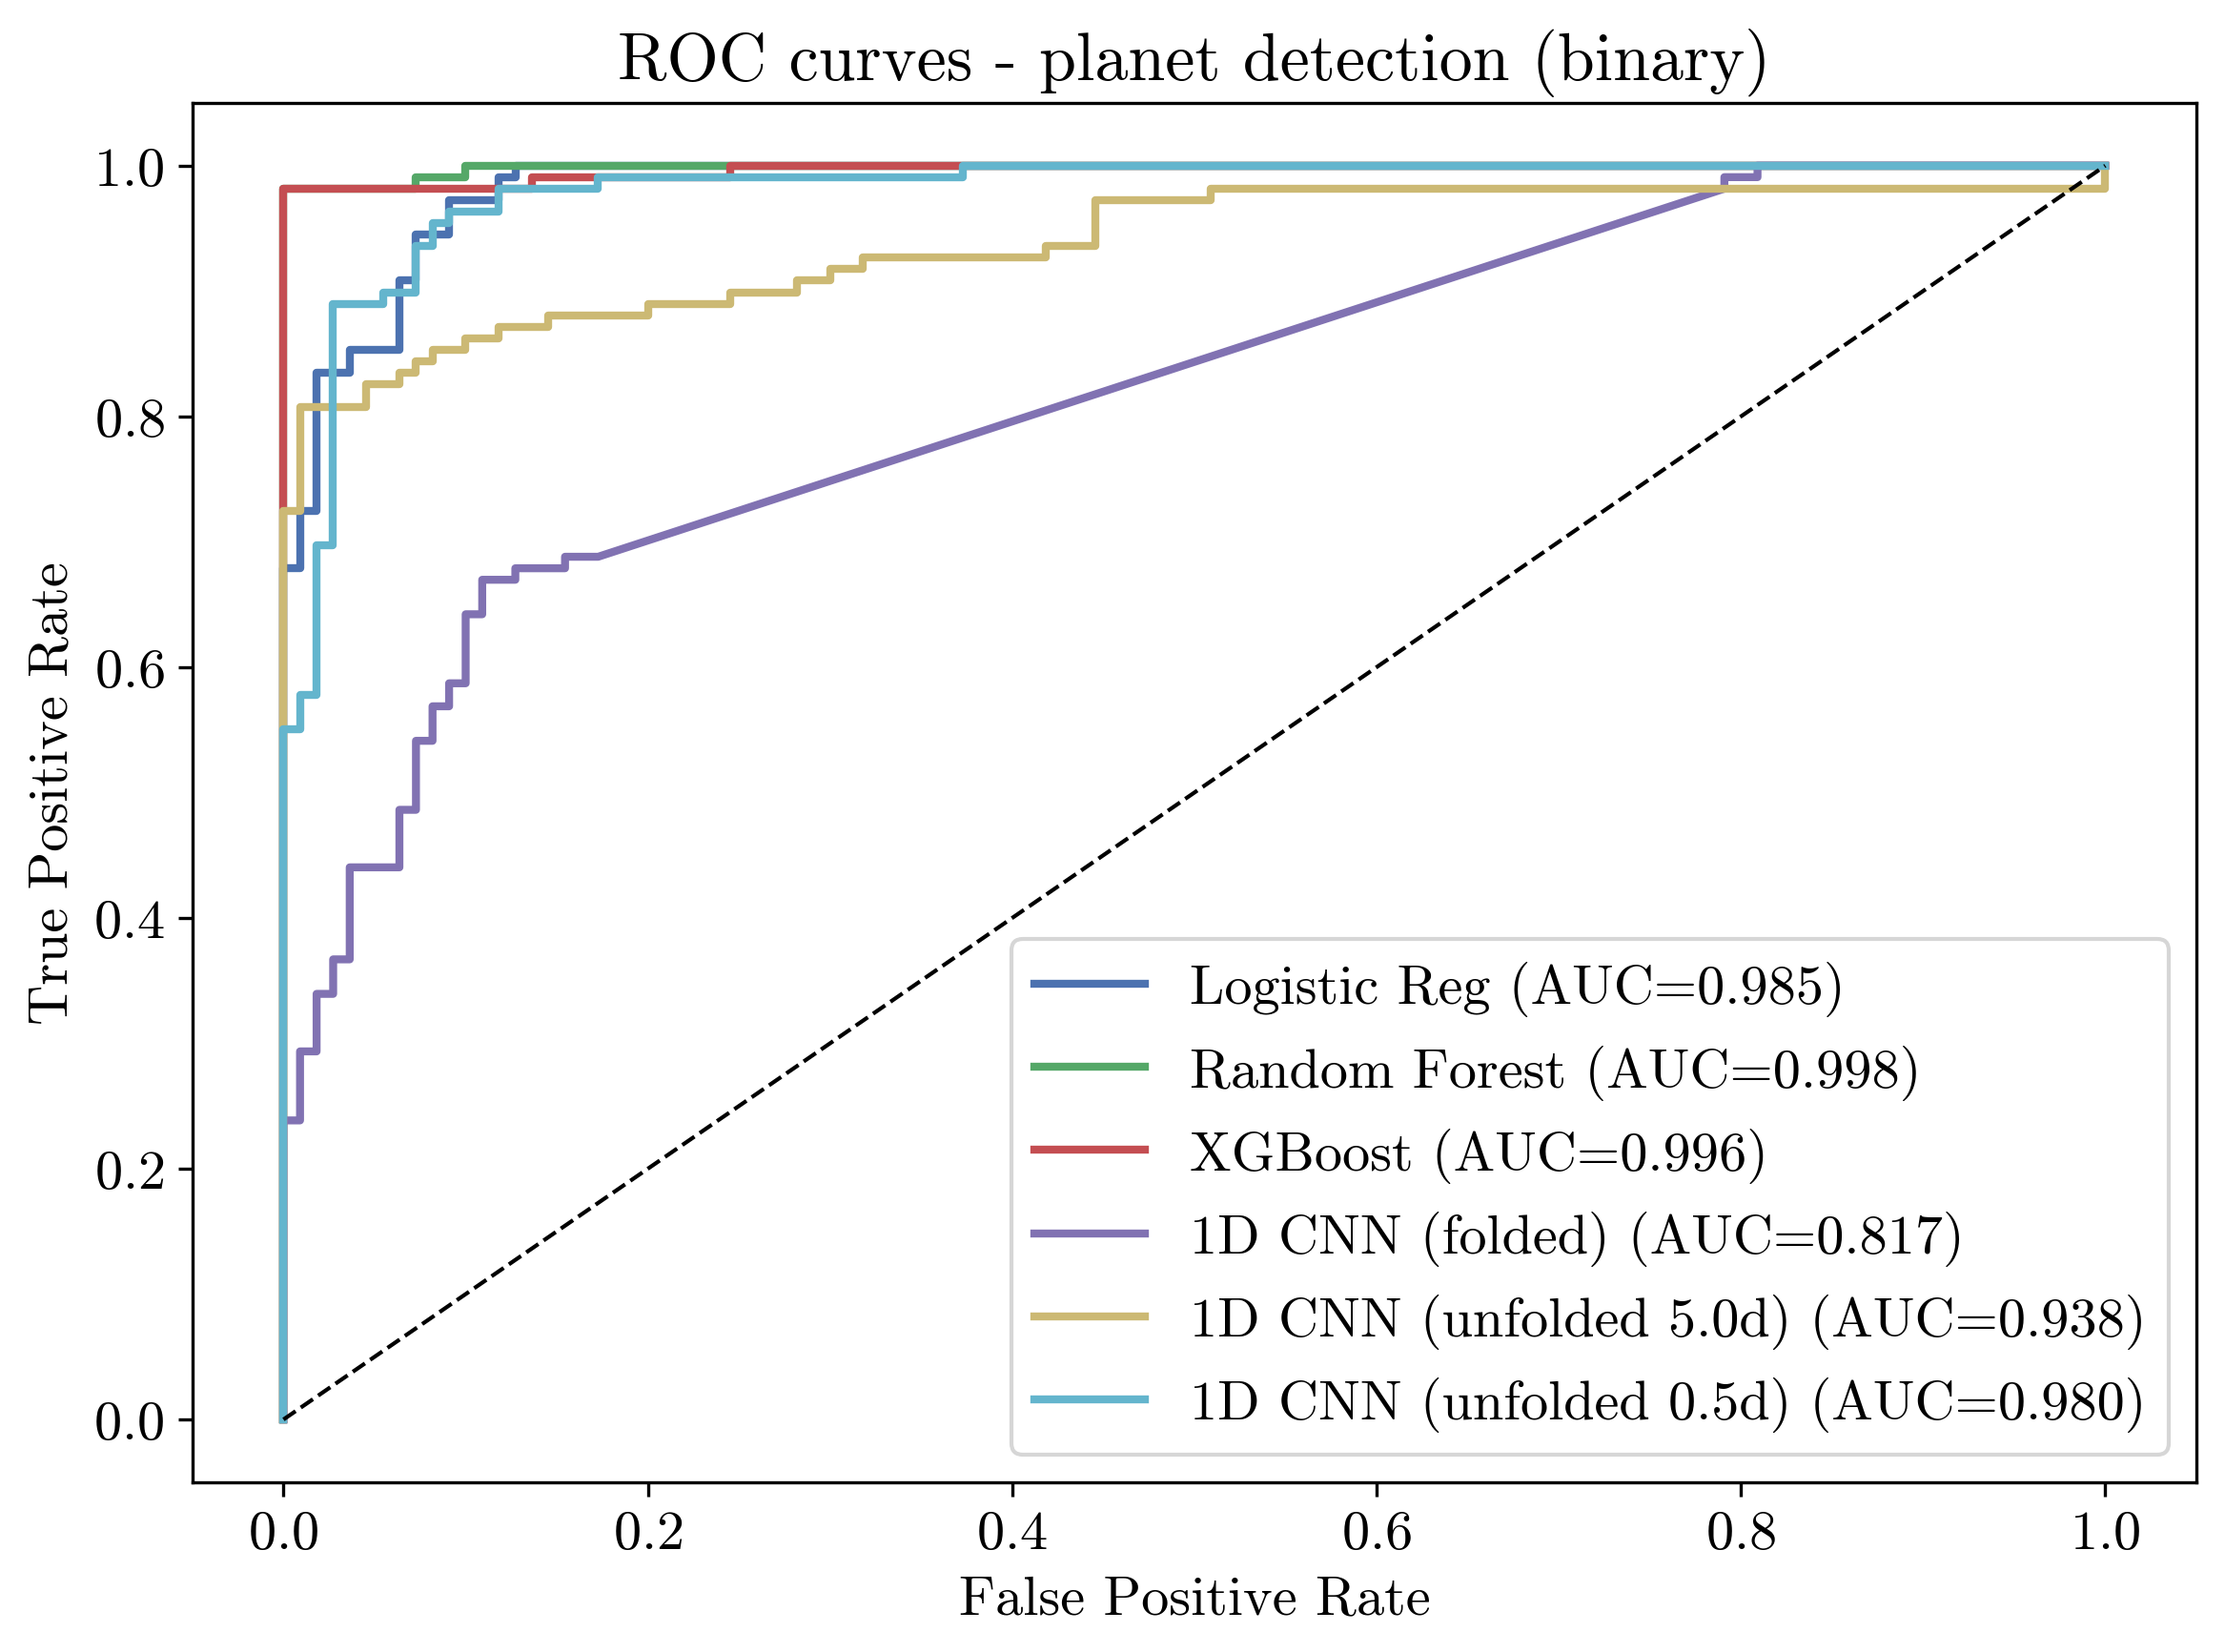

In [57]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for key, r in all_results.items():
    if key == "bls": continue  # BLS doesn't have a probability score, so skip ROC
    fpr, tpr, _ = roc_curve(yb_test, r["prob"])
    ax.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves - planet detection (binary)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### §7.2 — Stratified recovery (planet-bearing test curves)

In [36]:
# Best tabular model by AUC
best_tab_key = max((k for k in ["logreg", "rf", "xgb"]),
                   key=lambda k: results[k]["auc"])
best_tab = results[best_tab_key]
print(f"Best tabular: {best_tab['name']}")

planet_test_mask = (yb_test == 1)
df_planet_test   = df.iloc[idx_test][planet_test_mask].copy()
prob_best_tab    = best_tab["prob"][planet_test_mask]
prob_cnn         = results["cnn_unfolded_0.5d"]["prob"][planet_test_mask]

df_planet_test["pred_bls"]     = bls_pred_test[planet_test_mask]
df_planet_test["pred_tab"]     = (prob_best_tab >= 0.5).astype(int)
df_planet_test["pred_cnn"]     = (prob_cnn      >= 0.5).astype(int)

def recall_table(subset_mask, label):
    sub = df_planet_test[subset_mask] if subset_mask is not None else df_planet_test
    print(f"\n{label} (n={len(sub)}):")
    for col, name in [("pred_bls","BLS"), ("pred_tab",best_tab["name"]), ("pred_cnn","CNN")]:
        print(f"  {name:20s}: {sub[col].mean():.1%}")

recall_table(None, "All planet curves")
recall_table(df_planet_test["transit_depth_ppm"] < 200, "Shallow (<200 ppm)")
recall_table(df_planet_test["transit_depth_ppm"] >= 200, "Deep (≥200 ppm)")
recall_table(df_planet_test["planet_period_days"] >= 15, "Long period (≥15 d)")
recall_table(df_planet_test["planet_period_days"] < 15,  "Short period (<15 d)")

Best tabular: Random Forest

All planet curves (n=109):
  BLS                 : 96.3%
  Random Forest       : 98.2%
  CNN                 : 89.0%

Shallow (<200 ppm) (n=39):
  BLS                 : 92.3%
  Random Forest       : 94.9%
  CNN                 : 74.4%

Deep (≥200 ppm) (n=70):
  BLS                 : 98.6%
  Random Forest       : 100.0%
  CNN                 : 97.1%

Long period (≥15 d) (n=48):
  BLS                 : 93.8%
  Random Forest       : 97.9%
  CNN                 : 77.1%

Short period (<15 d) (n=61):
  BLS                 : 98.4%
  Random Forest       : 98.4%
  CNN                 : 98.4%


### §7.3 — Recovery fraction vs activity, radius, depth

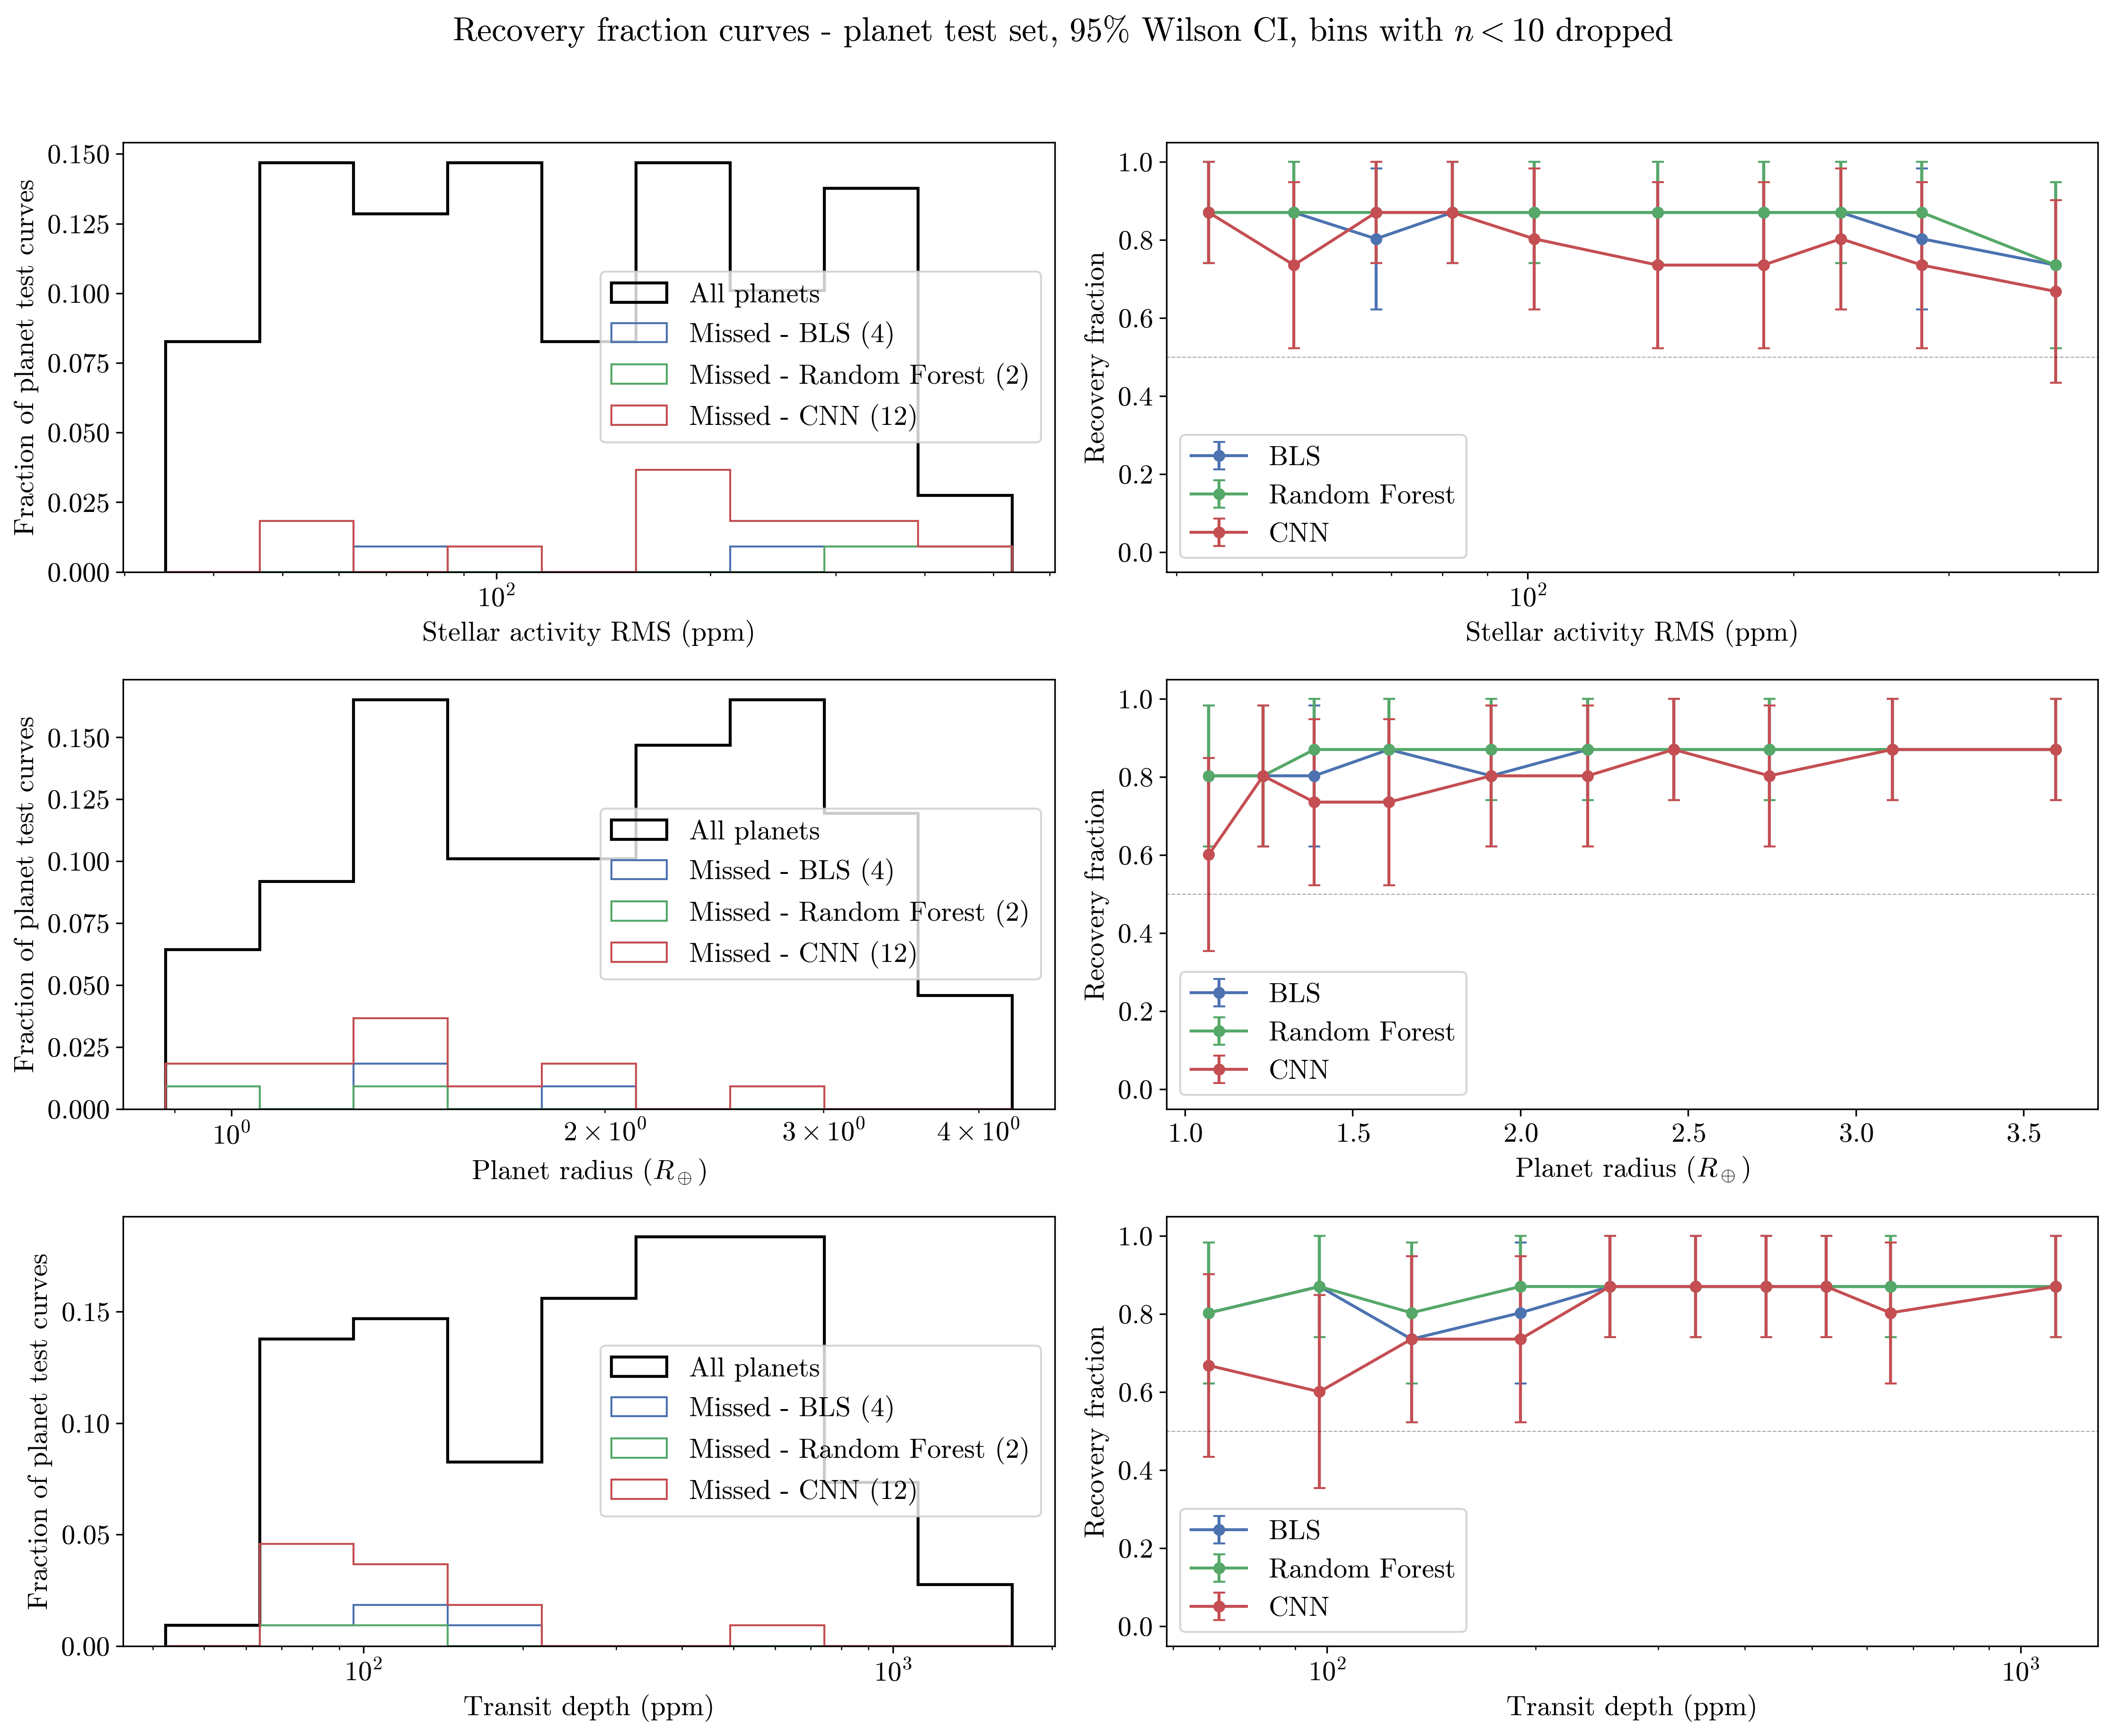

In [60]:
MIN_BIN = 10  # drop bins with fewer planet curves than this

def wilson_ci(k, n, z=1.96):
    """Wilson score interval. Returns (lo, centre, hi)."""
    if n == 0:
        return np.nan, np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - margin, centre, centre + margin

def recovery_curve(ax, sub, x_col, x_label, predictors, n_bins=10, log_x=False):
    x = sub[x_col].values.astype(float)
    finite = x[np.isfinite(x)]
    edges = np.unique(np.quantile(finite, np.linspace(0, 1, n_bins + 1)))

    for col, name,color in predictors:
        y = sub[col].values.astype(float)
        ctrs, frac, lo_err, hi_err = [], [], [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            mask = (x >= lo) & (x <= hi)
            n = int(mask.sum())
            if n < MIN_BIN:
                continue
            k = int(y[mask].sum())
            lo_ci, cen, hi_ci = wilson_ci(k, n)
            ctrs.append(0.5 * (lo + hi))
            frac.append(cen)
            lo_err.append(cen - lo_ci)
            hi_err.append(hi_ci - cen)

        if not ctrs:
            continue
        ax.errorbar(np.array(ctrs), np.array(frac),
                    yerr=[np.array(lo_err), np.array(hi_err)],
                    fmt="o-", capsize=3, lw=1.5, ms=5,
                    label=name, color=color)

    ax.axhline(0.5, color="k", lw=0.5, ls="--", alpha=0.35)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Recovery fraction")
    if log_x:
        ax.set_xscale("log")
    ax.legend()


def missed_hist(ax, sub, x_col, x_label, predictors, n_bins=35, log_x=True):
    """Overlay 'all planets' vs 'missed by each model' histograms on one axis.
    sub        : planet-only DataFrame (e.g. df_planet_test), must contain
                 x_col and each prediction column in `predictors`.
    predictors : list of (col, name, color) — col holds 1=recovered, 0=missed.
    Bars are normalised by the TOTAL planet count, so the filled 'missed'
    histograms are directly comparable to the 'all' outline and to each other.
    """
    x = sub[x_col].values.astype(float)
    finite = x[np.isfinite(x) & (x > 0 if log_x else np.isfinite(x))]
    if finite.size == 0:
        ax.text(0.5, 0.5, f"no finite {x_col}", ha="center", transform=ax.transAxes)
        return
    n_all = len(x)
    if log_x:
        edges = np.geomspace(finite.min() * 0.9, finite.max() * 1.1, n_bins)
    else:
        edges = np.linspace(finite.min(), finite.max(), n_bins)

    # All planets — outline
    ax.hist(x, bins=edges, weights=np.ones(n_all) / n_all,
            histtype="step", color="k", lw=1.5, label="All planets")

    # Missed, per model — filled, normalised by total so heights are fractions
    for col, name, color in predictors:
        missed = x[sub[col].values == 0]
        if missed.size:
            ax.hist(missed, bins=edges, weights=np.ones(missed.size) / n_all,
                    histtype="step", color=color,
                    label=f"Missed - {name} ({missed.size})")
        else:
            # nothing missed → note it in the legend rather than drawing nothing
            ax.plot([], [], color=color, lw=4, alpha=0.35,
                    label=f"Missed - {name} (0)")

    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Fraction of planet test curves")
    ax.legend()


predictors = [
    ("pred_bls", "BLS", 'C0'),
    ("pred_tab", best_tab["name"], 'C1'),
    ("pred_cnn", "CNN", 'C2'),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

missed_hist(ax1,df_planet_test,'act_rms',"Stellar activity RMS (ppm)",
            predictors,n_bins=10,log_x=True)

recovery_curve(ax2, df_planet_test,
               "act_rms", "Stellar activity RMS (ppm)",
               predictors, n_bins=10, log_x=True)
#axes[0].set_title("Recovery vs Activity level")

missed_hist(ax3,df_planet_test,'planet_radius_earth',r"Planet radius ($R_\oplus$)",
            predictors,n_bins=10,log_x=True)

recovery_curve(ax4, df_planet_test,
               "planet_radius_earth", r"Planet radius ($R_\oplus$)",
               predictors, n_bins=10)
#axes[1].set_title("Recovery vs Planet radius")

missed_hist(ax5,df_planet_test,'transit_depth_ppm',r"Transit depth (ppm)",
            predictors,n_bins=10,log_x=True)

recovery_curve(ax6, df_planet_test,
               "transit_depth_ppm", "Transit depth (ppm)",
               predictors, n_bins=10, log_x=True)
#axes[2].set_title("Recovery vs Transit depth")

plt.suptitle(
    fr"Recovery fraction curves - planet test set, 95% Wilson CI, bins with $n<${MIN_BIN} dropped",
    y=1.02,
)
plt.tight_layout()
plt.show()


### §7.4 — Precision-recall curves & matched-FPR operating points

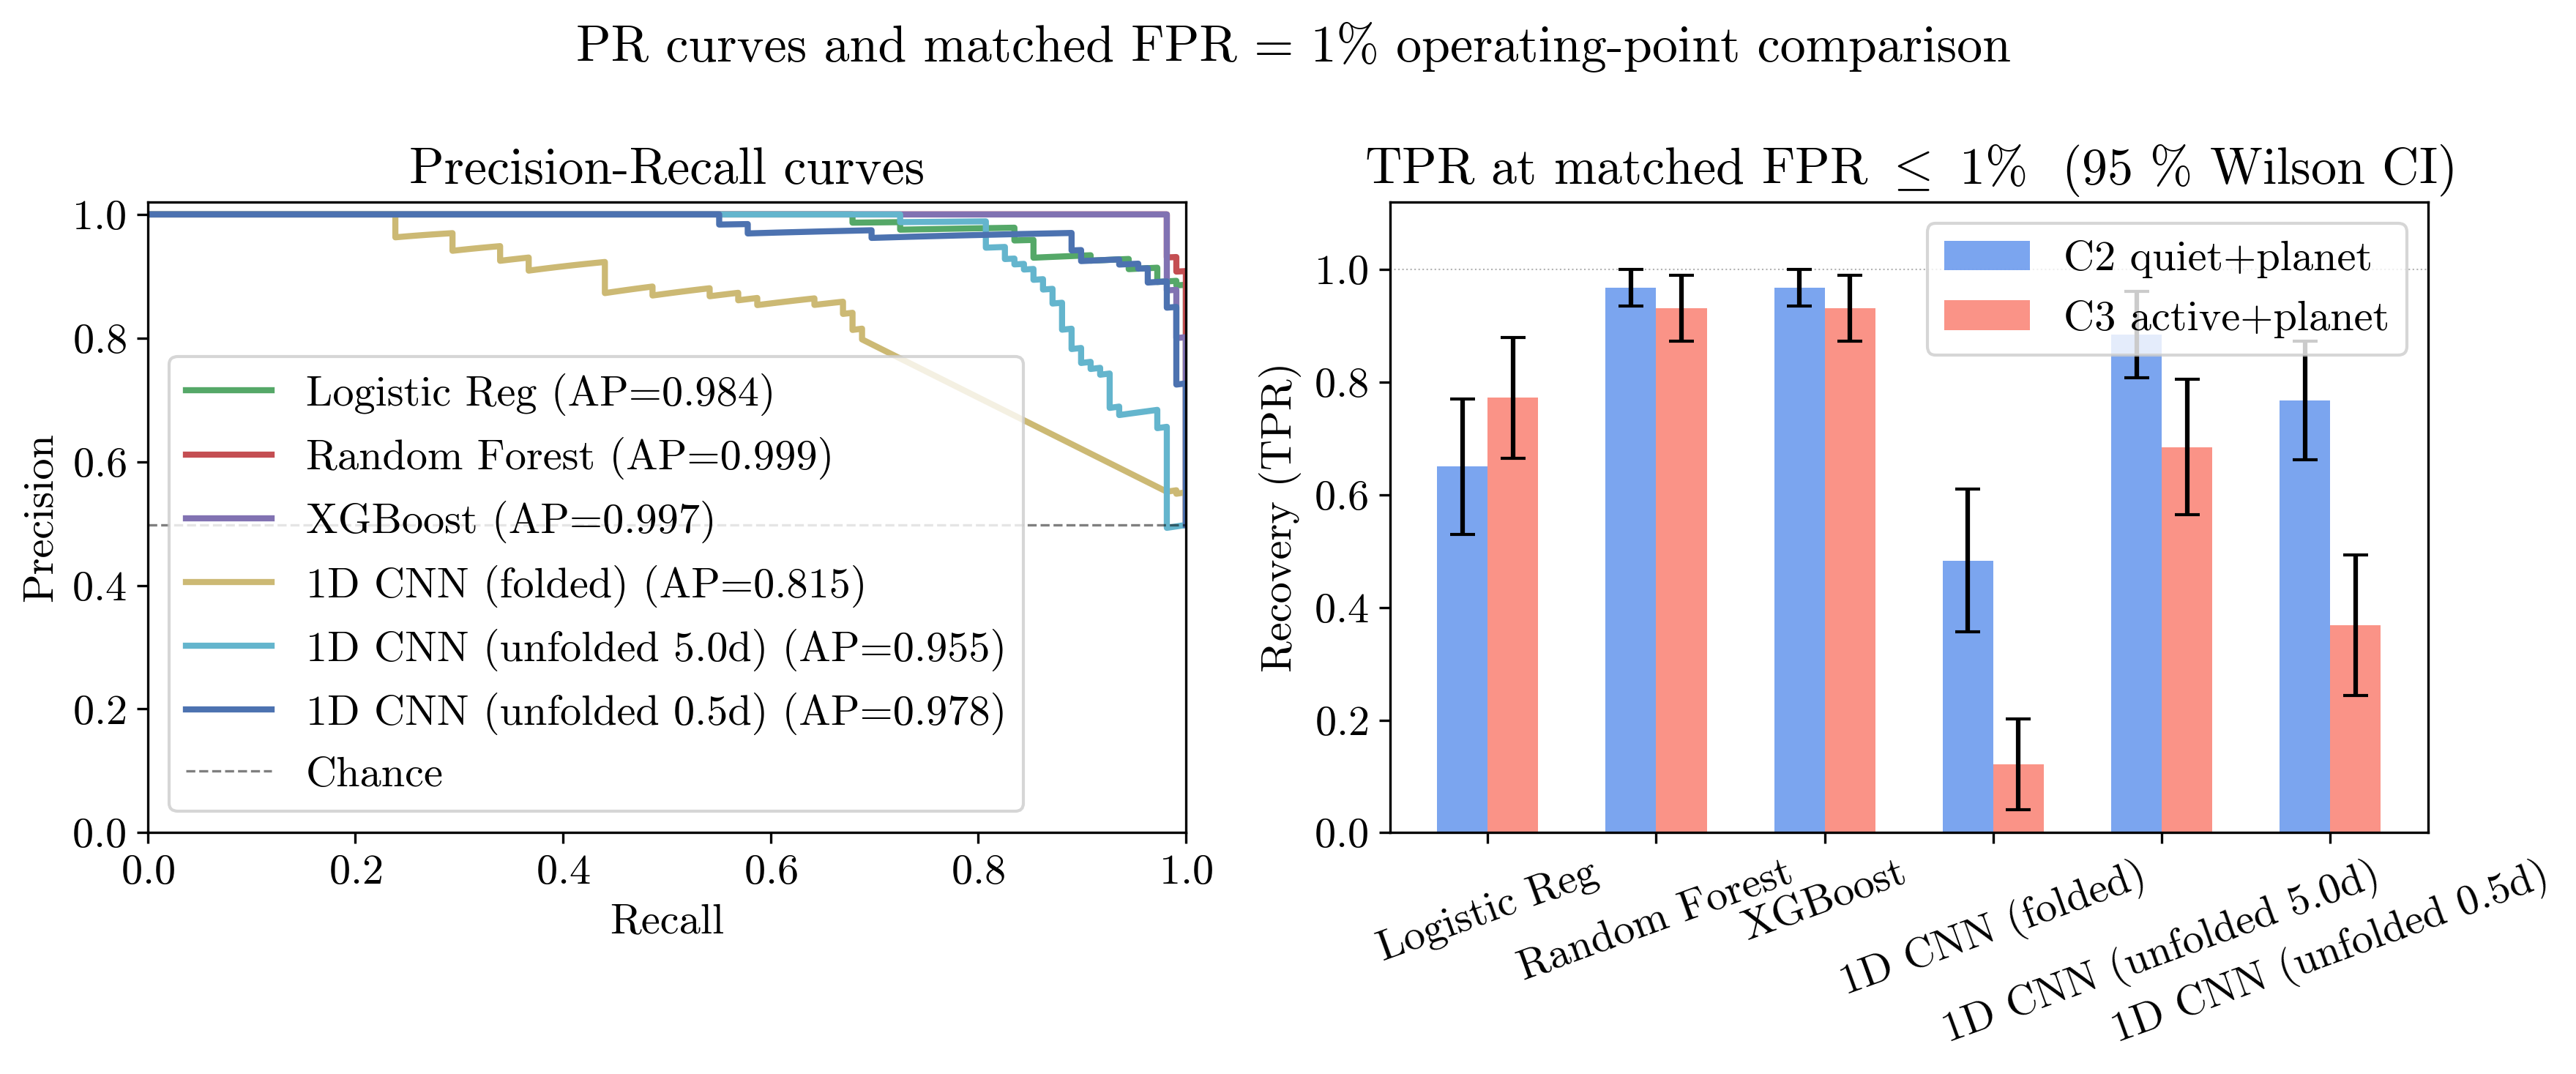

Recovery at matched FPR <= 1%:


,Actual FPR,Overall TPR,C2 quiet+planet,C3 active+planet
Model,,,,
Logistic Reg,0.91%,71.7% [63.4%-80.0%],65.0% [53.0%-77.1%],77.3% [66.5%-88.0%]
Random Forest,0.00%,96.5% [93.6%-99.5%],96.8% [93.6%-100.0%],93.1% [87.2%-99.0%]
XGBoost,0.00%,96.5% [93.6%-99.5%],96.8% [93.6%-100.0%],93.1% [87.2%-99.0%]
1D CNN (folded),0.91%,30.1% [21.6%-38.5%],48.3% [35.7%-61.0%],12.2% [4.1%-20.3%]
1D CNN (unfolded 5.0d),0.91%,79.7% [72.3%-87.0%],88.4% [80.7%-96.1%],68.5% [56.5%-80.5%]
1D CNN (unfolded 0.5d),0.91%,57.5% [48.4%-66.6%],76.7% [66.2%-87.3%],36.8% [24.3%-49.3%]


In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve

TARGET_FPR = 0.01   # fix global FPR at 1 % to compare recovery across methods

_COLORS = {
    "bls":    'C0',
    "logreg": "C1",
    "rf":     "C2",
    "xgb":    "C3",
    "cnn_folded":    "C4",
    "cnn_unfolded_5.0d": "C5",
    "cnn_unfolded_0.5d": "C6",
}

fig, (ax_pr, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))

n_pos = int((yb_test == 1).sum())
n_c2  = int((y4_test == 2).sum())
n_c3  = int((y4_test == 3).sum())

_bar_data = []
_tbl_rows = []

for key, r in all_results.items():
    if key == "bls": continue  # BLS doesn't have a probability score, so skip PR curve
    prob  = r["prob"]
    name  = r["name"]
    color = _COLORS.get(key, "gray")

    # ── Precision-recall curve ────────────────────────────────────────────────
    prec, rec, _ = precision_recall_curve(yb_test, prob)
    ap = average_precision_score(yb_test, prob)
    ax_pr.plot(rec, prec, label=f"{name} (AP={ap:.3f})", lw=2, color=color)

    # ── Matched-FPR operating point ───────────────────────────────────────────
    # roc_curve guarantees len(thresholds) == len(fpr) == len(tpr),
    # with fpr[0]=0, tpr[0]=0 at the sentinel threshold max(score)+1.
    fpr_arr, tpr_arr, thresh_roc = roc_curve(yb_test, prob)
    valid  = np.where(fpr_arr <= TARGET_FPR)[0]   # always non-empty (fpr[0]=0)
    idx_m  = valid[-1]                             # max TPR still within FPR budget
    t_m    = thresh_roc[idx_m]

    pred_m = (prob >= t_m).astype(int)
    k_all  = int(pred_m[yb_test == 1].sum())
    k_c2   = int(pred_m[y4_test == 2].sum())
    k_c3   = int(pred_m[y4_test == 3].sum())

    lo_all, cen_all, hi_all = wilson_ci(k_all, n_pos)
    lo_c2,  cen_c2,  hi_c2  = wilson_ci(k_c2,  n_c2)
    lo_c3,  cen_c3,  hi_c3  = wilson_ci(k_c3,  n_c3)

    _bar_data.append((name, color,
                      cen_c2, cen_c2 - lo_c2, hi_c2 - cen_c2,
                      cen_c3, cen_c3 - lo_c3, hi_c3 - cen_c3))
    _tbl_rows.append({
        "Model":             name,
        "Actual FPR":        f"{fpr_arr[idx_m]:.2%}",
        "Overall TPR":       f"{cen_all:.1%}  [{lo_all:.1%}-{hi_all:.1%}]",
        "C2 quiet+planet":   f"{cen_c2:.1%}  [{lo_c2:.1%}-{hi_c2:.1%}]",
        "C3 active+planet":  f"{cen_c3:.1%}  [{lo_c3:.1%}-{hi_c3:.1%}]",
    })

# ── PR panel ──────────────────────────────────────────────────────────────────
ax_pr.axhline((yb_test == 1).mean(), color="k", ls="--", lw=0.8, alpha=0.5,
              label="Chance")
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02)
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curves")
ax_pr.legend()

# ── Bar panel: C2 vs C3 TPR at matched FPR ───────────────────────────────────
_names  = [d[0] for d in _bar_data]
x       = np.arange(len(_names))
w       = 0.3

_c2 = np.array([[d[3], d[2], d[4]] for d in _bar_data]).T  # lo_err, cen, hi_err
_c3 = np.array([[d[6], d[5], d[7]] for d in _bar_data]).T

ax_bar.bar(x - w/2, _c2[1], w, yerr=[_c2[0], _c2[2]],
           label="C2 quiet+planet",  color="cornflowerblue", capsize=4, alpha=0.85)
ax_bar.bar(x + w/2, _c3[1], w, yerr=[_c3[0], _c3[2]],
           label="C3 active+planet", color="salmon",         capsize=4, alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(_names, rotation=20)
ax_bar.set_ylabel("Recovery (TPR)")
ax_bar.set_ylim(0, 1.12)
ax_bar.axhline(1.0, color="k", lw=0.5, ls=":", alpha=0.3)
ax_bar.set_title(fr"TPR at matched FPR $\leq$ {TARGET_FPR:.0%}  (95 % Wilson CI)")
ax_bar.legend()

plt.suptitle(
    f"PR curves and matched FPR = {TARGET_FPR:.0%} operating-point comparison"
)
plt.tight_layout()
plt.show()

_matched_df = pd.DataFrame(_tbl_rows).set_index("Model")
print(fr"Recovery at matched FPR <= {TARGET_FPR:.0%}:")
display(_matched_df)


## §8 — Error Analysis

In [39]:
# Venn counts: BLS vs best ML (planet curves only)
bls_rec  = df_planet_test["pred_bls"].astype(bool)
ml_rec   = df_planet_test["pred_tab"].astype(bool)
cnn_rec  = df_planet_test["pred_cnn"].astype(bool)

print("Recovery overlap (planet test curves):")
print(f"  BLS only:          {(bls_rec & ~ml_rec).sum()}")
print(f"  {best_tab['name']:15s} only: {(~bls_rec & ml_rec).sum()}")
print(f"  CNN only:          {(~bls_rec & ~ml_rec & cnn_rec).sum()}")
print(f"  BLS + ML + CNN:    {(bls_rec & ml_rec & cnn_rec).sum()}")
print(f"  None:              {(~bls_rec & ~ml_rec & ~cnn_rec).sum()}")

Recovery overlap (planet test curves):
  BLS only:          0
  Random Forest   only: 2
  CNN only:          0
  BLS + ML + CNN:    96
  None:              2


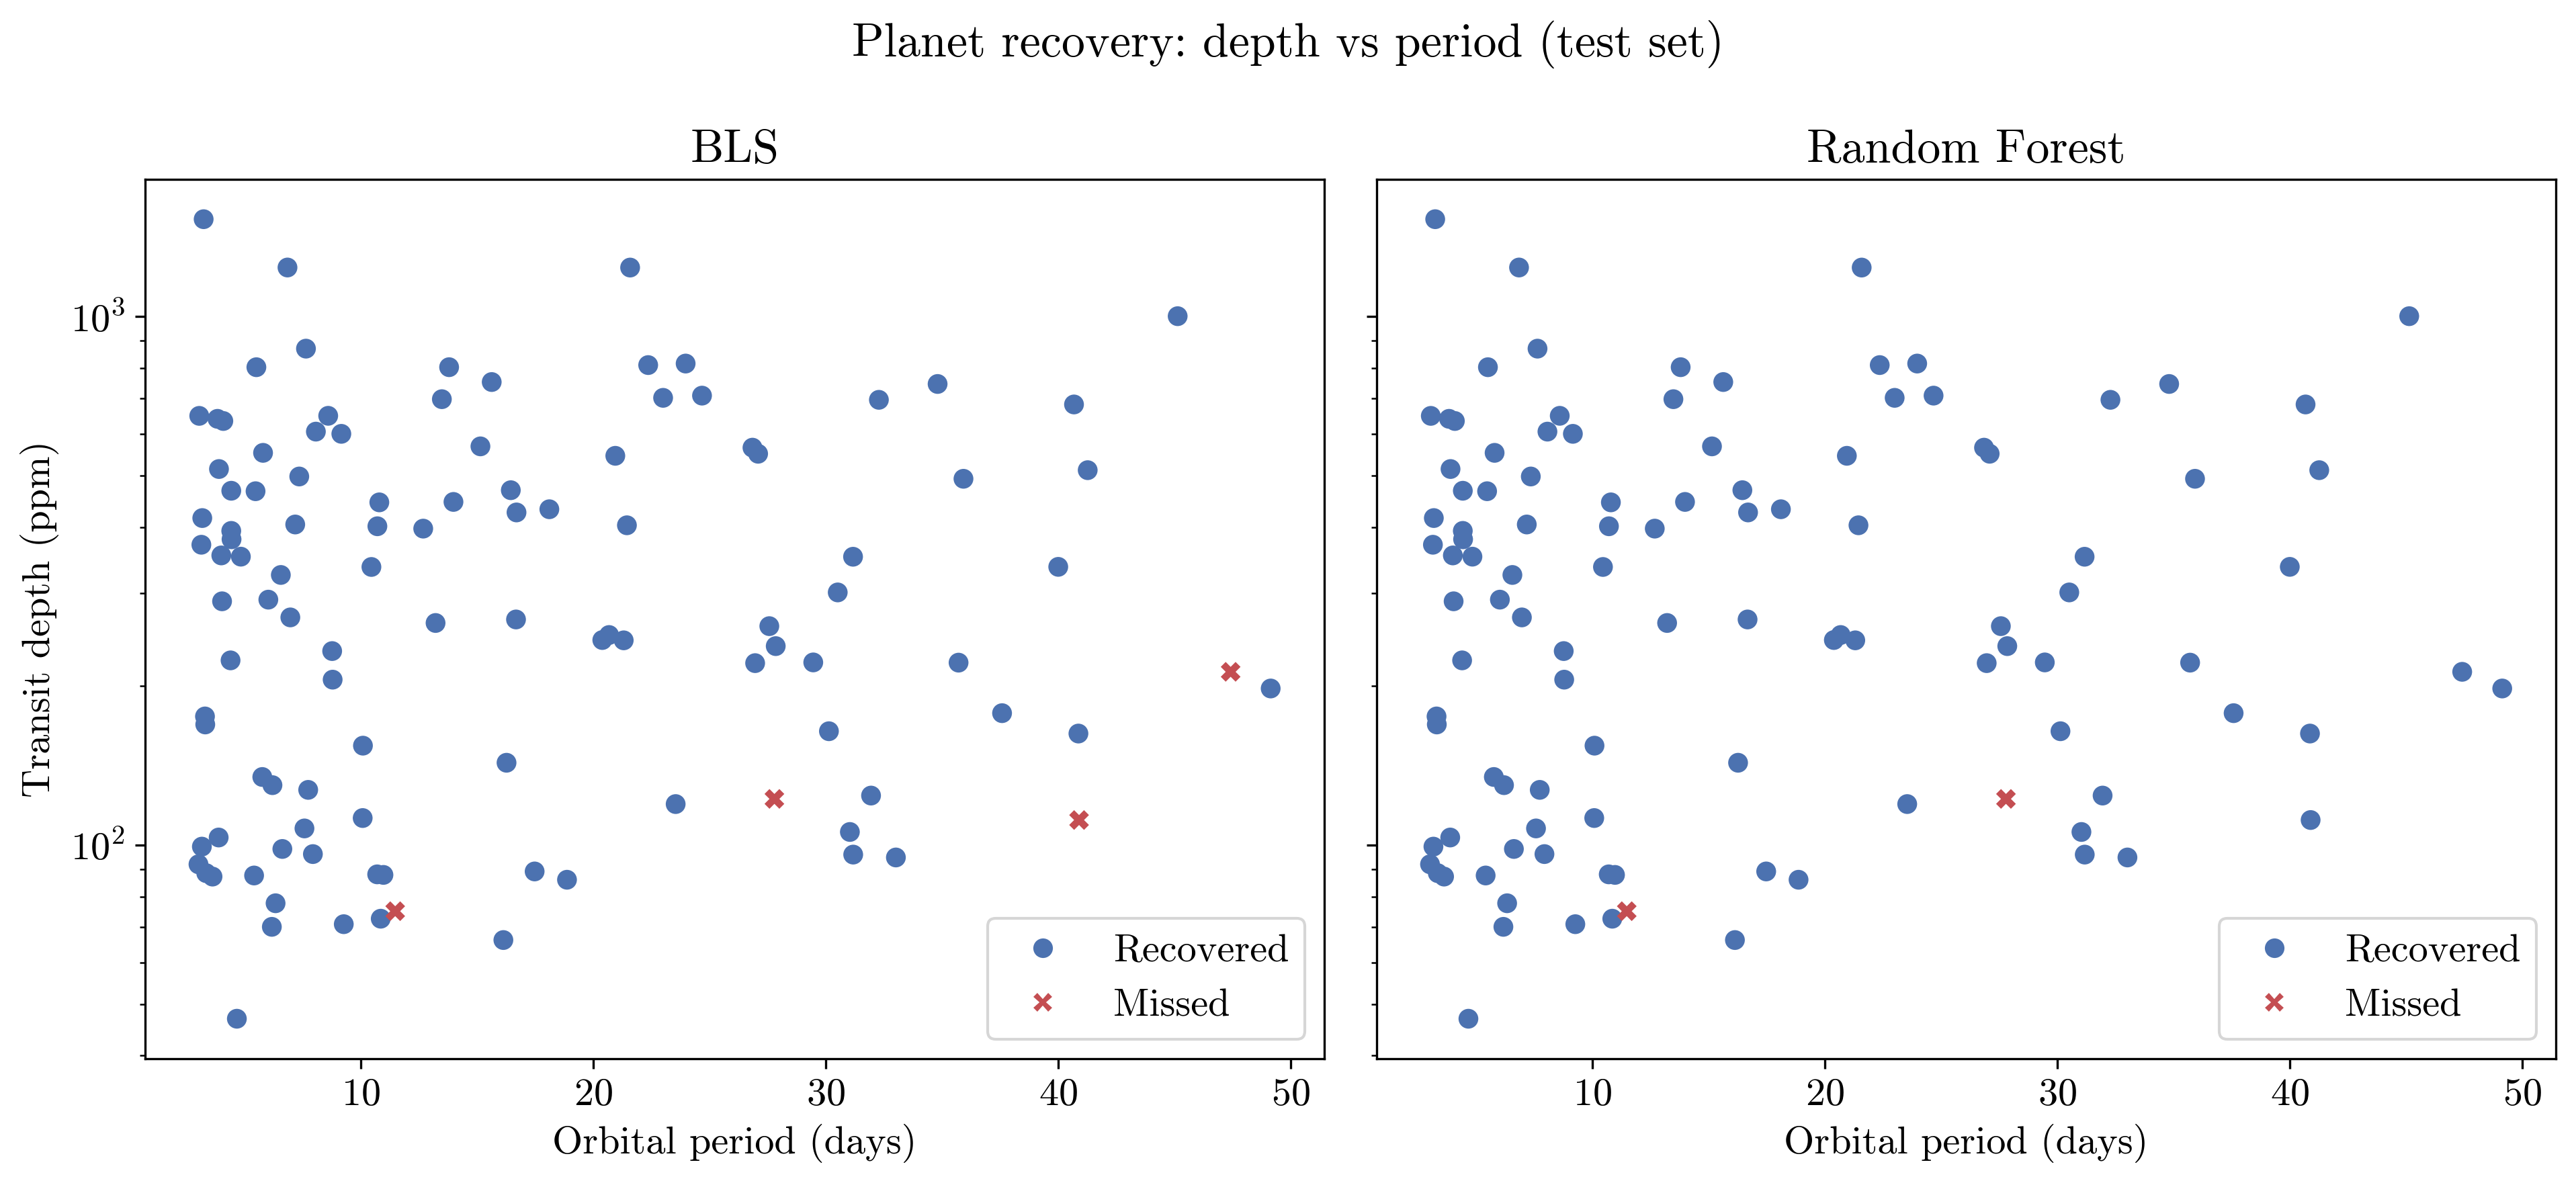

In [77]:
# Scatter: depth vs period, coloured by ML recovery status (best model)
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, col, name in [
    (axes[0], "pred_bls", "BLS"),
    (axes[1], "pred_tab", best_tab["name"]),
]:
    # 1. Split and plot Recovered (1) -> Circle ('o')
    df_rec = df_planet_test[df_planet_test[col] == 1]
    ax.scatter(
        df_rec["planet_period_days"],
        df_rec["transit_depth_ppm"],
        c="C0", marker="o", s=50, edgecolors="none"
    )
    
    # 2. Split and plot Missed (0) -> Cross ('X')
    df_missed = df_planet_test[df_planet_test[col] == 0]
    ax.scatter(
        df_missed["planet_period_days"],
        df_missed["transit_depth_ppm"],
        c="C2", marker="X", s=50, edgecolors="none"  # Changed marker to 'X' here
    )
    
    # Proxy artists for legend (matched to the markers above)
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='C0', markersize=8, label='Recovered'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='C2', markersize=8, label='Missed'),
    ]
    
    ax.legend(handles=handles)
    ax.set_xlabel("Orbital period (days)")
    ax.set_title(name)
    ax.set_yscale("log")

axes[0].set_ylabel("Transit depth (ppm)")
plt.suptitle("Planet recovery: depth vs period (test set)")
plt.tight_layout()
plt.show()

Planets recovered by Random Forest but NOT BLS: 2 curves
label
2    1
3    1


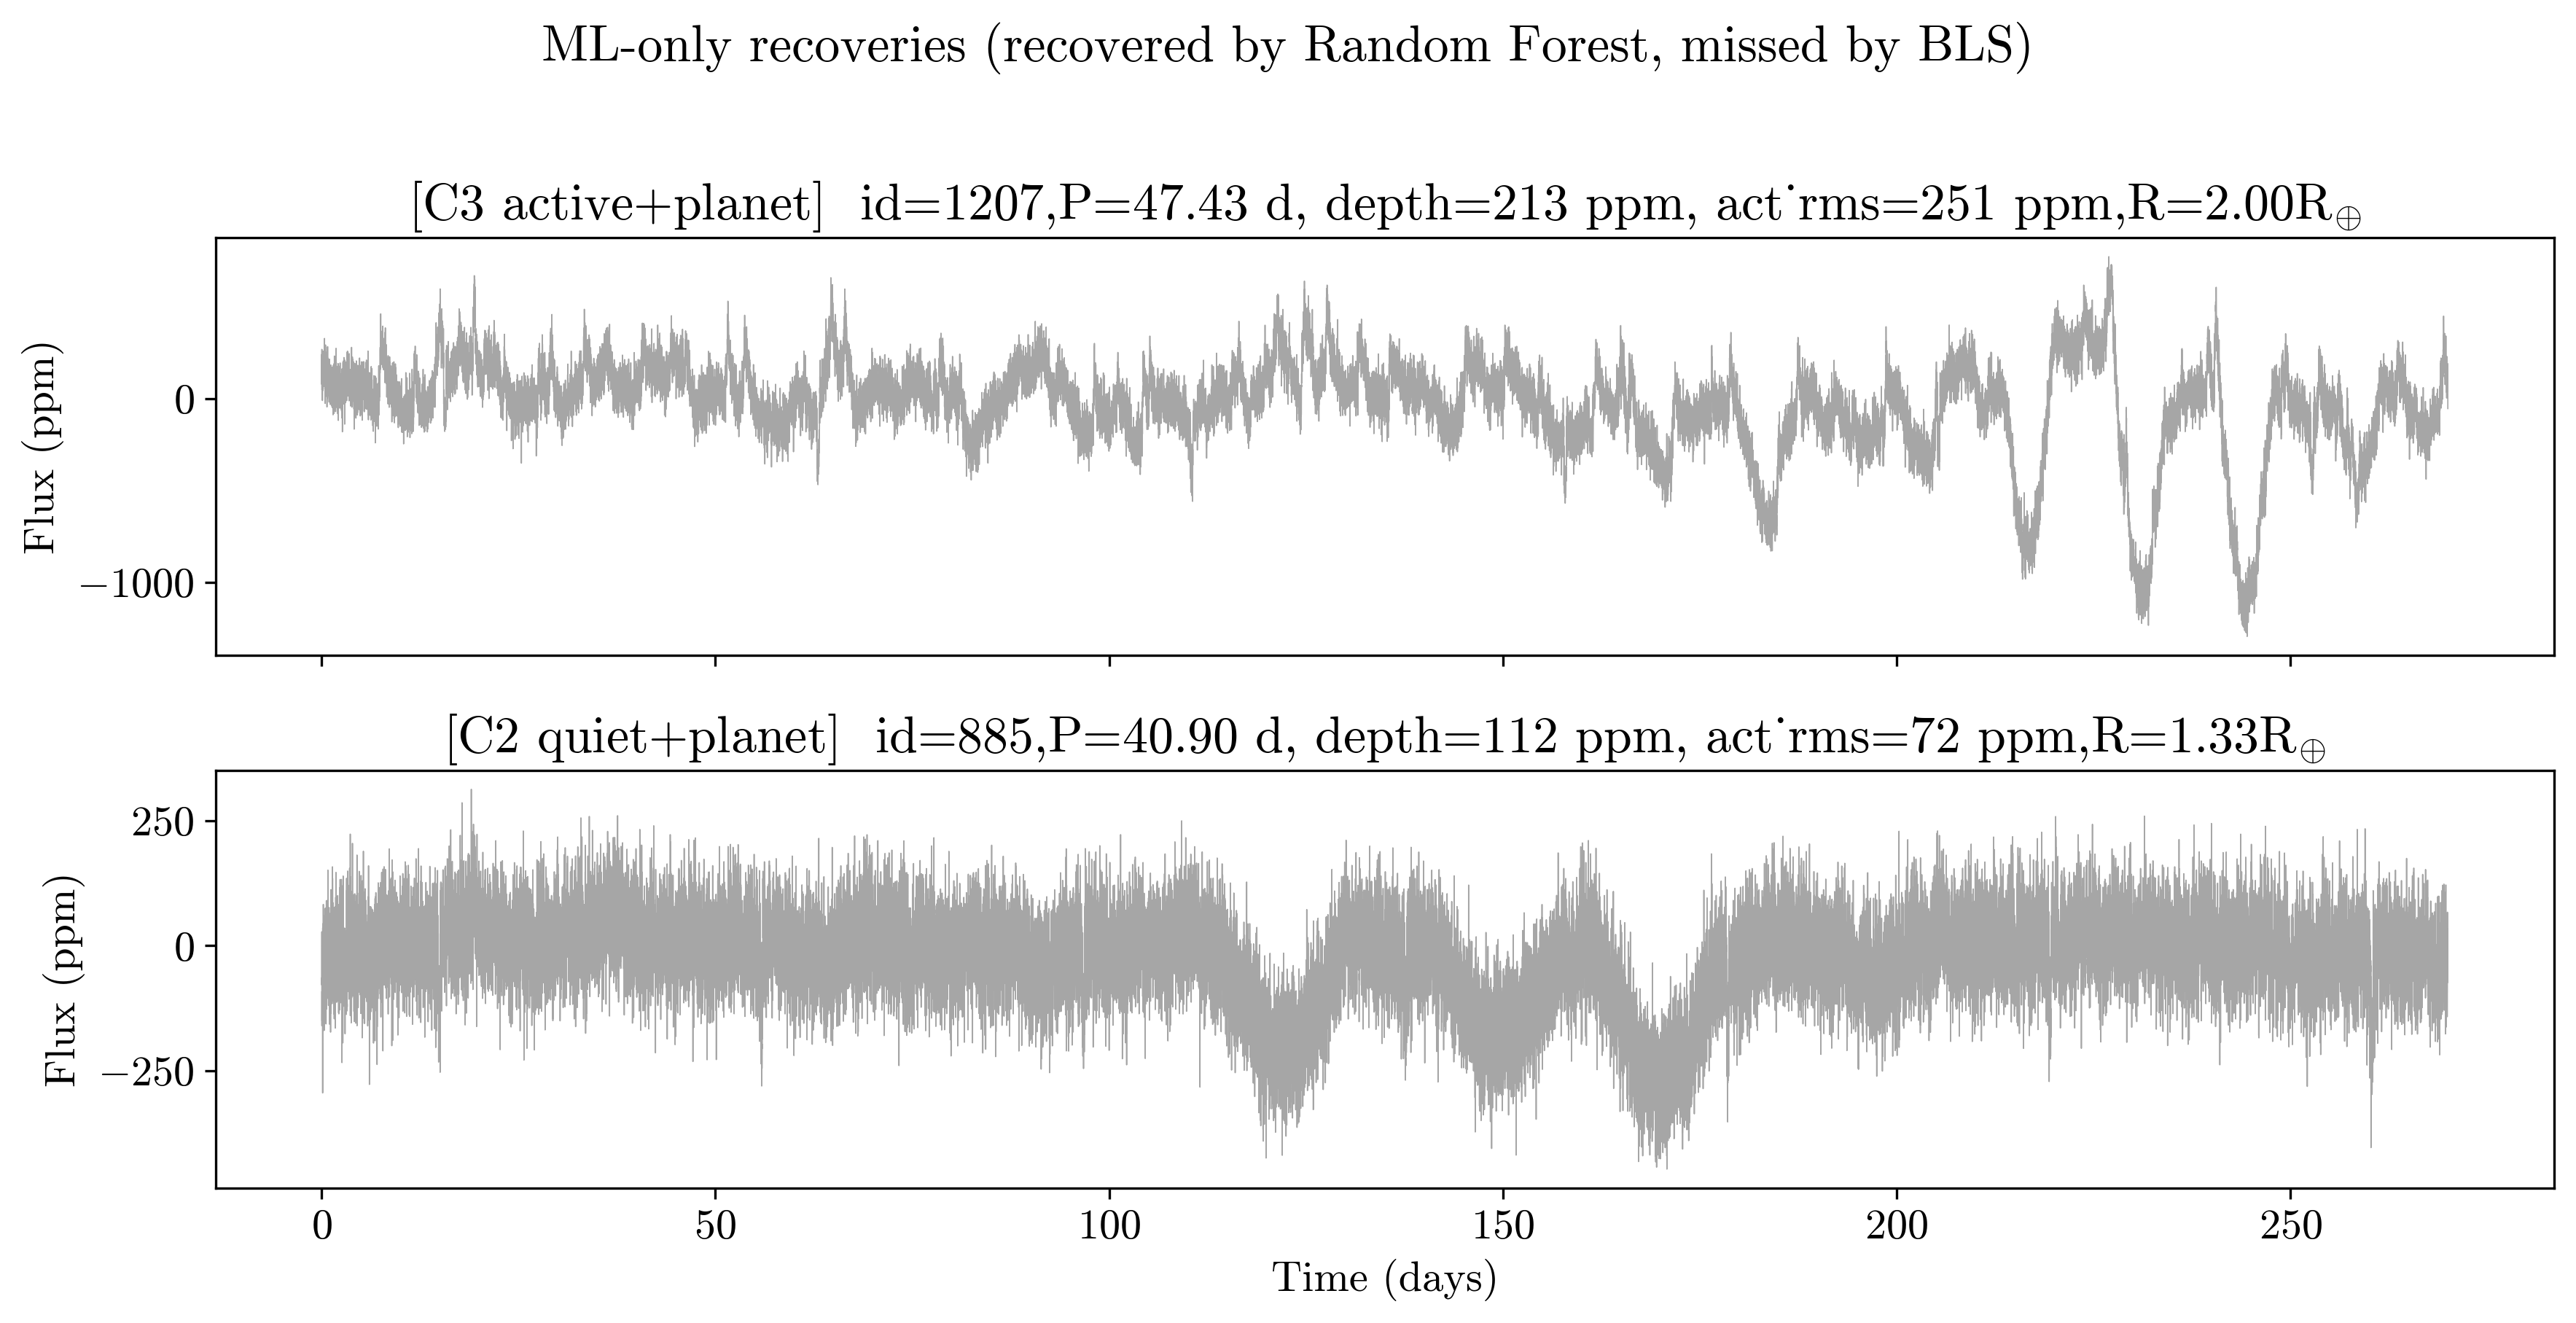

In [87]:
# Show example light curves: ML recovers, BLS misses (BOTH planet classes)
_bls = df_planet_test["pred_bls"].astype(bool).values
_ml  = df_planet_test["pred_tab"].astype(bool).values
ml_only = df_planet_test[(~_bls) & _ml]         

print(f"Planets recovered by {best_tab['name']} but NOT BLS: {len(ml_only)} curves")
print(ml_only["label"].value_counts().sort_index().to_string())

n_show = len(ml_only)                             
if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(12, 3 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]

    CLASS_TAG = {2: "C2 quiet+planet", 3: "C3 active+planet"}
    for ax, (fid, row) in zip(axes, ml_only.iterrows()):
        loc = df.index.get_loc(fid)              
        ax.plot(time, flux[loc], lw=0.4, color="gray", alpha=0.7)
        ax.set_ylabel("Flux (ppm)")
        cls = int(row["label"])
        
        r_earth = r"$\text{R}_{\oplus}$"
        ax.set_title(
            f"[{CLASS_TAG.get(cls, f'C{cls}')}]  id={int(fid)},"
            f"P={row['planet_period_days']:.2f} d, "
            f"depth={row['transit_depth_ppm']:.0f} ppm, act_rms={row['act_rms']:.0f} ppm,R={row['planet_radius_earth']:.2f}{r_earth}"
        )
    axes[-1].set_xlabel("Time (days)")
    plt.suptitle(f"ML-only recoveries (recovered by {best_tab['name']}, missed by BLS)", y=1.01)
    plt.tight_layout(); plt.show()
else:
    print("No ML-only recoveries in test set.")

## §9 — Summary, Conclusions & Future Work

### What was done
Phase 4 benchmarked machine-learning planet detectors against the Phase-3 BLS classical baseline on 1,457 simulated PLATO-like light curves across four classes (C0 quiet/no-planet, C1 active/no-planet, C2 quiet/planet, C3 active/planet). Two families were tested: **tabular models** (LogReg, RF, XGBoost) on BLS statistics plus stellar/activity metadata, and **1-D CNNs** on the light curve directly — phase-folded (§5) and unfolded at 30-min cadence with two detrend windows (§6). All metrics are on a single held-out test set (~55 curves/class) unless noted as out-of-fold (OOF); confidence intervals are Wilson 95%.

### Headline results (test set, 0.5 threshold)

| Model | FPR C0 | FPR C1 (active FP) | TPR C2 | TPR C3 (active planet) | AUC |
|---|---|---|---|---|---|
| BLS baseline | 7.1% | **98.1%** | 98.2% | 94.3% | — |
| Random Forest | 0.0% | 3.7% | 100% | 96.2% | 0.998 |
| XGBoost | 0.0% | 0.0% | 100% | 96.2% | 0.996 |
| CNN folded | 25.0% | 1.9% | 85.7% | 49.1% | 0.817 |
| CNN unfolded 5.0 d | 0.0% | 0.0% | 80.4% | 54.7% | 0.938 |
| CNN unfolded 0.5 d | 1.8% | 3.7% | 96.4% | 81.1% | 0.980 |

### Target Research Questions

**1. At what activity level does classical detection begin to fail?** 

On this dataset it largely *doesn't* fail at detection: BLS recovers 96.0% of C2 and 89.5% of C3 planets. Its failure is in **false alarms** — FPR on active no-planet stars (C1) is 98.1%, i.e. BLS triggers on almost every active star. So the answer is not a clean activity threshold but a regime statement: across the sampled activity range BLS *detects* planets well yet is *swamped by activity-driven false positives*. A crisp activity-failure threshold is not extractable here because the injected planets are too easy for activity to suppress detection (see Limitations).

**2. Does ML outperform the classical baseline?**

Yes, but the claim is layered and depends on the operating point:
- **As a false-positive filter on top of BLS:** decisively. RF/XGBoost cut FPR(C1) from 98% to 0-4% while holding TPR(C3) at 96%. This is the strongest result.
- **At matched FPR (≤1%), comparing recovery fairly (§8.6):** RF/XGBoost recover 96.5% overall (C3: 93%); the best CNN (unfolded 5.0d) reaches 79.7% overall (C3: 68.5%); BLS-as-detector and the folded CNN trail badly (folded C3: 12%).
- **As an *independent* detector (metadata only, no BLS — §4.5 ablation):** no. Stellar+activity features alone reach only AUC ~0.65-0.72 (OOF), barely above chance for the FP problem. Activity metadata carries *some* planet-discriminating signal but adds essentially nothing on top of BLS (All ≈ BLS-only).

**3. Are flares more damaging than rotational spot modulation?**

**Not answerable from this dataset.** The headline unfolded model produced only 2/54 C1 false alarms, and binning those by activity component (§6.8) shows no significant separation (n far too small; spots/flares/activity co-vary by construction). Definitive attribution needs a controlled spots-only / flares-only / both generation grid (Future Work).

**4. Are shallow transits disproportionately lost?**
Yes, and consistently across methods (§8.4-8.5). Stratified recovery: shallow (<200 ppm) vs deep (≥200 ppm) is BLS 92.3% vs 98.6%, RF 94.9% vs 100%, CNN 74.4% vs 97.1%. The CNN is hit hardest by shallow transits; long-period (few-transit) planets show the same pattern (CNN 77% long vs 98% short period). Shallow + long period is the common hard regime for every method.

**5. Which model is most robust, and why?**

**Random Forest (with BLS features)** is most robust overall: highest matched-FPR recovery (96.5%), flattest across the depth/period/activity strata, and near-zero false alarms. The "why" (§4.4 importance): it leans on `bls_power`/`bls_depth_ppm`, which degrade gracefully, while adding activity features only as a weak FP filter.
Among the CNNs the picture is operating-point dependent and worth stating carefully: at the 0.5 threshold the unfolded 0.5d model looks best (AUC 0.980, C3 81%), but **at matched 1% FPR the unfolded 5.0d model recovers more active planets** (C3 68.5% vs 36.8%) — keeping rotation context makes it more conservative about false alarms and more reliable at a strict operating point. The folded CNN is the weakest detector throughout (it inherits the BLS fold period, so when BLS picks an activity harmonic the transit smears out).

### Conclusions
- BLS remains an excellent *detector* but a poor *discriminator* of activity: its near-100% C1 false-positive rate is the core problem ML solves here.
- The largest, most defensible gain is **ML as a post-BLS false-positive filter** (tabular RF/XGBoost), not as a standalone detector.
- Among CNNs, **unfolding beats folding** for active-star planets — global temporal context helps where phase-folding's period dependence hurts — but the best unfolded variant depends on the chosen operating point, not AUC alone.
- AUC is misleading for this imbalanced task: it ranks the unfolded 0.5d CNN above 5.0d, while matched-FPR analysis (the operationally meaningful comparison) reverses that for active planets.

### Limitations
- **The injected planet population is too easy.** BLS detects ~90-96% of planets, so there is little headroom for ML to demonstrate superior *detection*; the contest is almost entirely about false-alarm suppression. This caps how interesting Q1 can be.
**Possible BLS feature leakage.** `bls_depth_ppm` is only well-defined when BLS triggers, so it may partly encode the label. The §4.5 ablation already compares "BLS (full)" vs "BLS (clean, depth dropped)" — clean RF holds up (OOF AUC 0.980 vs 0.989), suggesting the effect is modest, but a fuller leakage audit is warranted.
- **Single-split CNN numbers.** All CNN metrics are on \~55 curves/class (Wilson CIs are wide, e.g. C3 81% is ±~6%). Only the tabular ablation is out-of-fold.
- **Folded vs unfolded resolution mismatch** is only partially controlled; the folded CNN ran at 128 bins, the unfolded at 30-min cadence.
- **Activity-component attribution (Q3) is unresolved** — co-varying parameters and too few false alarms.

### Future work

1. **Regenerate a harder planet population** — smaller radii (1-2.5 R⊕), longer periods (few transits over 270 d), grazing geometries; keep a 40/40/20 easy/marginal/hard mix so BLS-only AUC falls to ~0.85 and FPR(C1) approaches the project premise. This unblocks a real answer to Q1.

2. **Tabular ML without leaky BLS features.** The §4.5 ablation shows BLS-clean (depth/depth-err dropped) already holds up out-of-fold, but a full re-run of the §4 tabular pipeline — training, tuning, and the §8 comparison — on the leakage-free feature set would confirm how much of the headline FPR reduction survives once the label-encoding risk of `bls_depth_ppm` is removed entirely. If RF/XGBoost still cut FPR(C1) to single digits with only `bls_power`/`bls_period` + metadata, the post-BLS-filter result is fully secured; if performance drops, it quantifies how much was leakage.

3. **Controlled spots/flares/both ablation grid** at matched amplitudes — the only clean way to answer Q3 (flares vs spot modulation).

4. **Out-of-fold / per-fold CNN evaluation** so CNN numbers are comparable to the tabular OOF results and CIs tighten.

6. **Cadence sweep for the folded CNN** (256/512/1024 bins) to make the folded-vs-unfolded comparison fully fair.

7. **Two-stage pipeline** — unfolded CNN for sensitivity + a BLS/tabular precision screen to remove activity false positives — and a two-branch CNN (folded local view + unfolded global view) à la Shallue & Vanderburg.

8. **Folded diagnostic with inkected peroid** to confirm whether the folded CNN's weakness is upstream BLS period recovery rather than morphology learning.